# How binary convolution works

**Workflow 4 — analyse representations.** Pattern search on a binary pitch × time
grid is a **2D sliding-window** comparison: place a small kernel on the host
matrix, score the overlap, move the window, repeat.

This notebook is the accessible explainer. It starts on **toy grids** you can
mix and match (including **valid** vs **same** padding on the same windows),
then uses the same math on Bach *Ein feste Burg*:

1. one placement (window · kernel → score) on a toy host;
2. **valid** vs **same** padding on those same toy windows;
3. the sliding-window process on Bach (including a short animation);
4. **stride** and **kernel size** on the Bach crop.

Apply the ideas in
[`binary_pattern_search.ipynb`](binary_pattern_search.ipynb). Representation
rotation lives in [`binary_roundtrip.ipynb`](binary_roundtrip.ipynb).

Common-notation MEI only. Companion guide:
[Analyse representations](../docs/guides/analysis.md).

**What you do**

1. In the toy cell, pick `TOY_KERNEL_NAME` and `TOY_HOST_NAME` (or leave the defaults).
2. Leave `PLACEMENT_MODE = "random"` and change `RANDOM_SEED` to see new windows.
3. Run the padding cell — it reuses the same host, kernel, and windows.
4. Then parse Bach. If using the sample URL and it is not cached yet, set `RUN_FETCH = True` once.


In [67]:
# You can leave this cell unchanged.
try:
    from camat import find_camat_root, parse_files, resolve_mei_source
    from camat.music_utils import create_binary_matrix_bundle
    from camat.pattern_search import resize_kernel
except ModuleNotFoundError:
    import setup_camat
    from camat import find_camat_root, parse_files, resolve_mei_source
    from camat.music_utils import create_binary_matrix_bundle
    from camat.pattern_search import resize_kernel

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import Rectangle
from IPython.display import HTML, display


## 1. Toy host and kernel

No MEI required. For host $M$ and kernel $K$ with top-left at $(i, j)$:

$$
S(i,j)=\sum_{u,v} M[i+u,j+v]\cdot K[u,v]
$$

On binary grids this is the count of shared `1`s. **Normalised overlap**
divides by the number of active kernel cells so a perfect fit scores `1.0`:

$$
\hat S(i,j)=\frac{S(i,j)}{\sum K}\quad(\sum K>0)
$$

CAMAT's `normalized_overlap` metric is exactly this score.

The right-hand plot is an **overlap heatmap**: each cell is the normalised
score for **one** valid kernel position (one top-left $(i,j)$). White dots
mark the selected kernel positions drawn in the breakdowns below.

It is smaller than the host because **valid** convolution only keeps
placements where the kernel fits inside. For host $H\times W$ and kernel
$h\times w$ the number of those placements is

$$
N_{\text{valid}}=(H-h+1)\,(W-w+1)
$$

(at stride 1). **Same** padding (next section) instead yields $N_{\text{same}}=H\,W$.

At one placement the raw overlap cannot exceed the number of `1`s in the
kernel, nor the number of `1`s in that window, so normalised overlap is at
most `1.0`. CAMAT search exposes the same boundary choice as
`run_pattern_search(..., padding="valid"|"same")` (`valid` is the default).

**Student setup** in the next cell — those six lines only:

| Knob | Meaning |
| --- | --- |
| `TOY_KERNEL_NAME` | which pattern to match |
| `TOY_HOST_NAME` | which grid to search |
| `PLACEMENT_MODE` | `random` (default), `planted`, or `fixed` |
| `RANDOM_SEED` | new seed → new plant location and/or windows |
| `N_SHOW` | how many windows to draw |
| `FIXED_I`, `FIXED_J` | used only when mode is `fixed` |

Kernels: `hold`, `chord`, `step_down`, `step_up`, `scale`, `leap`, `block`,
`motif` (short phrase), `thirds` (two voices), `turn`, `cadence`, `texture`.

Hosts: `chorale` (four staggered lines plus a hidden copy), `sequence`
(repeated copies, shifted in pitch), `polyphony`, `planted`, `two_hits`,
`partial`, `busy`, `noise`.

`random` mode skips empty windows so every drawn patch contains at least one
`1`. Switch to `planted` to snap onto a hidden copy (`1.0` on `chorale` /
`sequence` / `planted` / `two_hits`).


Kernel 'motif': shape (4, 6), active=6
[[1 1 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]
Host 'chorale': shape (10, 18)
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0]
 [0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Planted copy at top-left: (i=5, j=12)
Set PLACEMENT_MODE = "planted" (or FIXED_I/FIXED_J) to snap onto a copy.
PLACEMENT_MODE='random', seed=0, showing 3 window(s): [(3, 7), (1, 11), (4, 4)]
  (i=3, j=7) window 1s=10
  (i=1, j=11) window 1s=10
  (i=4, j=4) window 1s=6


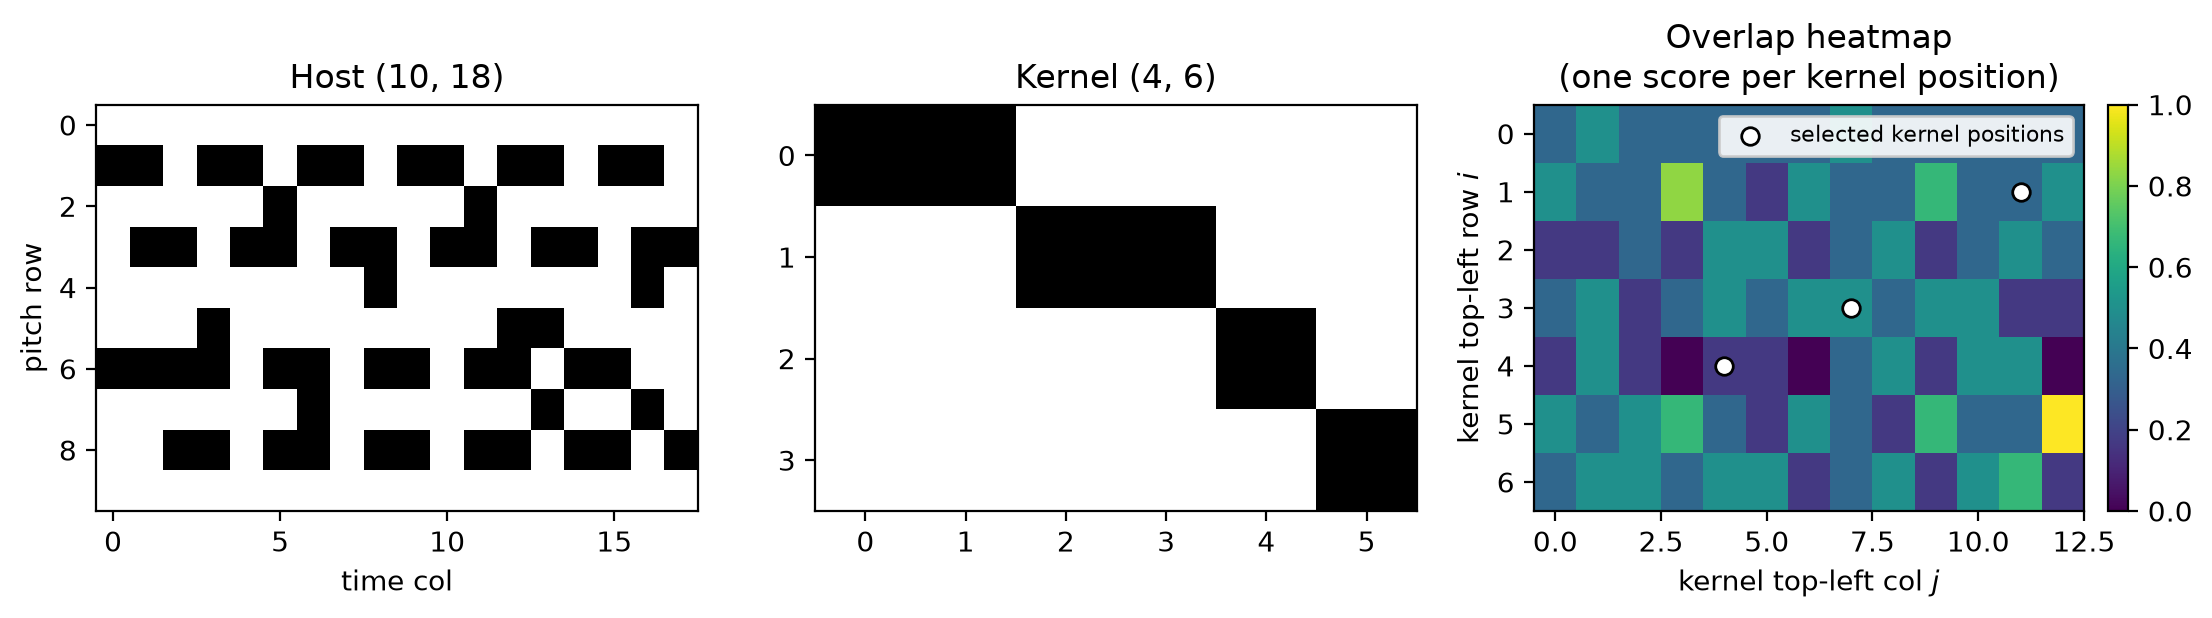

Overlap heatmap (7, 13): each cell is the normalised overlap for one valid kernel top-left. White dots = the selected positions below.
Placements at stride 1: valid (H-h+1)×(W-w+1) = (10-4+1)×(18-6+1) = 91; same H×W = 10×18 = 180.
Max raw overlap at one placement ≤ kernel 1s (6) and ≤ window 1s; normalised overlap is therefore in [0, 1].
Best normalised overlap: 1.000 at top-left (i=5, j=12)


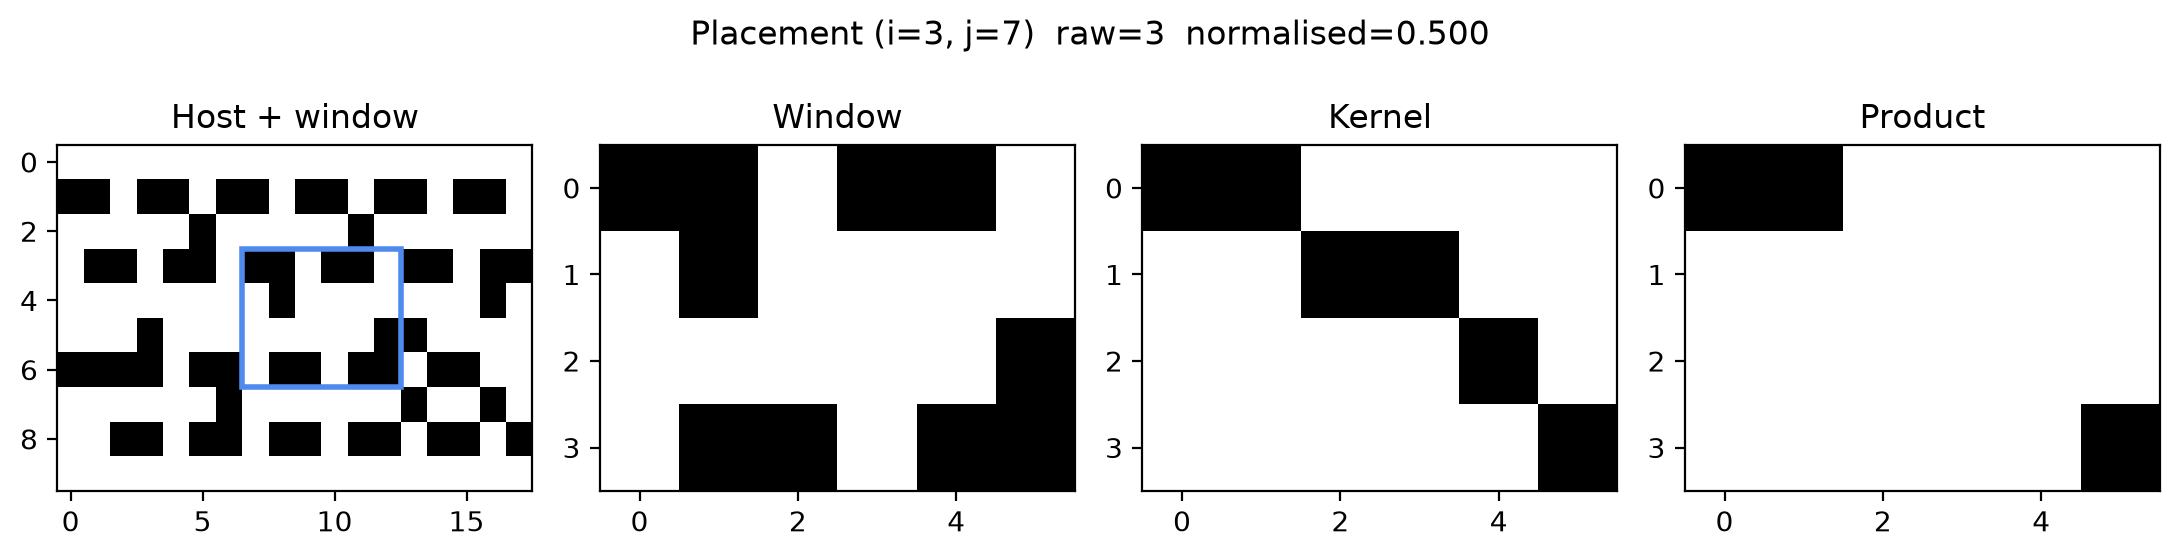

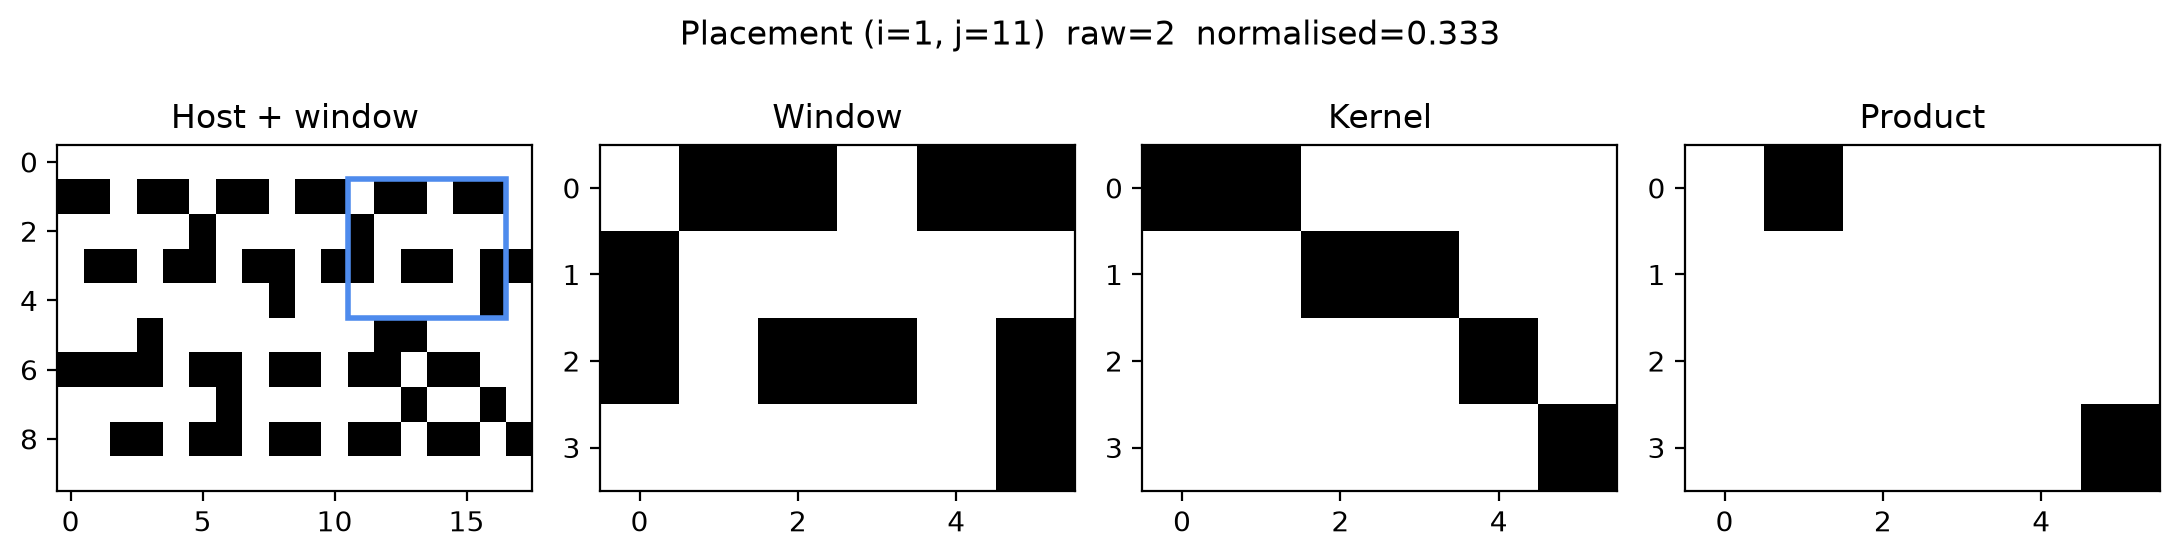

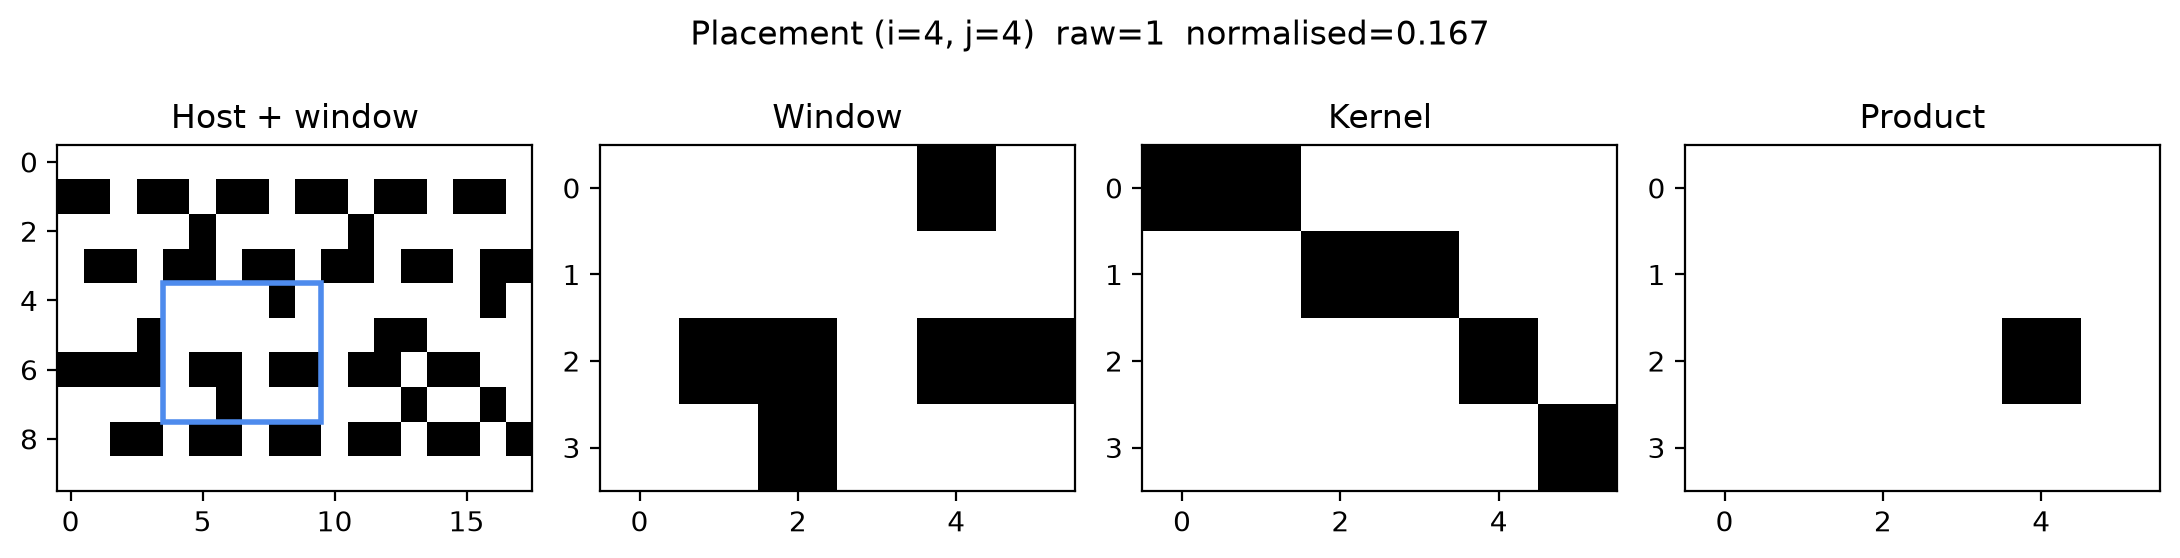

In [68]:
# Student setup — change these, then re-run this cell.
TOY_KERNEL_NAME = "motif"      # hold | chord | step_down | step_up | scale | leap | block | motif | thirds | turn | cadence | texture
TOY_HOST_NAME = "chorale"      # chorale | sequence | polyphony | planted | two_hits | partial | busy | noise
PLACEMENT_MODE = "random"      # random | planted | fixed
RANDOM_SEED = 0
N_SHOW = 3
FIXED_I, FIXED_J = 0, 2

# Helpers and catalogs below — leave unchanged unless you add your own kernel/host.

TOY_HOST_SHAPE = (10, 18)


def valid_placements(host_shape, kernel_shape, stride_y=1, stride_x=1):
    R, C = host_shape
    r, c = kernel_shape
    if r > R or c > C:
        return [], []
    rows = list(range(0, R - r + 1, max(1, int(stride_y))))
    cols = list(range(0, C - c + 1, max(1, int(stride_x))))
    return rows, cols


def all_valid_top_lefts(host_shape, kernel_shape, stride_y=1, stride_x=1):
    rows, cols = valid_placements(host_shape, kernel_shape, stride_y, stride_x)
    return [(i, j) for i in rows for j in cols]


def score_at(M, K, i, j, normalize=True):
    r, c = K.shape
    window = M[i : i + r, j : j + c]
    product = window * K
    raw = float(product.sum())
    denom = float(K.sum())
    norm = raw / denom if denom and normalize else raw
    return window, product, raw, norm


def pad_for_same(M, K):
    M = np.asarray(M, dtype=float)
    K = np.asarray(K, dtype=float)
    r, c = K.shape
    pad_y = r // 2
    pad_x = c // 2
    Mp = np.pad(M, ((pad_y, r - 1 - pad_y), (pad_x, c - 1 - pad_x)))
    return Mp, pad_y, pad_x


def convolution_map(M, K, stride_y=1, stride_x=1, normalize=True, padding="valid"):
    # padding='valid' matches CAMAT search (no pad).
    # padding='same' zero-pads so the score map can match the host shape at stride 1.
    M = np.asarray(M, dtype=float)
    K = np.asarray(K, dtype=float)
    if padding == "same":
        Mp, pad_y, pad_x = pad_for_same(M, K)
    elif padding == "valid":
        Mp = M
        pad_y = pad_x = 0
    else:
        raise ValueError("padding must be 'valid' or 'same'")

    rows, cols = valid_placements(Mp.shape, K.shape, stride_y=stride_y, stride_x=stride_x)
    scores = np.full((len(rows), len(cols)), np.nan)
    for ii, i in enumerate(rows):
        for jj, j in enumerate(cols):
            _, _, raw, norm = score_at(Mp, K, i, j, normalize=normalize)
            scores[ii, jj] = norm if normalize else raw
    return scores, rows, cols, {
        "pad_y": pad_y,
        "pad_x": pad_x,
        "padded_shape": Mp.shape,
    }


def show_placement(M, K, i, j, title=None):
    window, product, raw, norm = score_at(M, K, i, j, normalize=True)
    fig, axes = plt.subplots(1, 4, figsize=(11, 2.8))
    panels = [
        (M, "Host + window", True),
        (window, "Window", False),
        (K, "Kernel", False),
        (product, "Product", False),
    ]
    for ax, (data, label, draw_box) in zip(axes, panels):
        ax.imshow(data, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
        ax.set_title(label)
        if draw_box:
            ax.add_patch(
                Rectangle(
                    (j - 0.5, i - 0.5),
                    K.shape[1],
                    K.shape[0],
                    fill=False,
                    edgecolor="#4e8bed",
                    linewidth=2,
                )
            )
    fig.suptitle(
        title
        or f"Placement (i={i}, j={j})  raw={raw:.0f}  normalised={norm:.3f}"
    )
    fig.tight_layout()
    plt.show()
    return raw, norm


def _stamp(M, K, i, j):
    r, c = K.shape
    M[i : i + r, j : j + c] = np.maximum(M[i : i + r, j : j + c], K)
    return M


def _pick_top_left(host_shape, kernel_shape, rng):
    opts = all_valid_top_lefts(host_shape, kernel_shape)
    if not opts:
        raise ValueError(f"Kernel {kernel_shape} does not fit host {host_shape}.")
    return opts[int(rng.integers(0, len(opts)))]


def _add_walk(M, row, col, n_notes, rng, dur=2, steps=(-1, 0, 1)):
    R, C = M.shape
    for _ in range(n_notes):
        if 0 <= row < R and 0 <= col < C:
            M[row, col : min(col + dur, C)] = 1.0
        row = int(np.clip(row + int(rng.choice(list(steps))), 0, R - 1))
        col += dur + int(rng.integers(0, 2))
        if col >= C:
            break
    return M


TOY_KERNELS = {
    "hold": np.array([[1, 1, 1]], dtype=float),
    "chord": np.array([[1], [1], [1]], dtype=float),
    "step_down": np.array([[1, 1, 0], [0, 0, 1]], dtype=float),
    "step_up": np.array([[0, 0, 1], [1, 1, 0]], dtype=float),
    "scale": np.array(
        [
            [1, 0, 0],
            [0, 1, 0],
            [0, 0, 1],
        ],
        dtype=float,
    ),
    "leap": np.array(
        [
            [1, 0],
            [0, 0],
            [0, 1],
        ],
        dtype=float,
    ),
    "block": np.array([[1, 1], [1, 1]], dtype=float),
    "motif": np.array(
        [
            [1, 1, 0, 0, 0, 0],
            [0, 0, 1, 1, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1],
        ],
        dtype=float,
    ),
    "thirds": np.array(
        [
            [1, 1, 0, 1, 1, 0],
            [0, 0, 0, 0, 0, 0],
            [1, 1, 0, 1, 1, 0],
        ],
        dtype=float,
    ),
    "turn": np.array(
        [
            [0, 1, 0, 0],
            [1, 0, 1, 1],
            [0, 0, 0, 0],
            [0, 0, 0, 1],
        ],
        dtype=float,
    ),
    "cadence": np.array(
        [
            [1, 0, 1],
            [1, 0, 0],
            [1, 0, 1],
            [0, 0, 1],
        ],
        dtype=float,
    ),
    "texture": np.array(
        [
            [1, 0, 1, 1, 0],
            [1, 1, 0, 1, 0],
            [0, 1, 1, 0, 1],
            [1, 0, 0, 1, 1],
        ],
        dtype=float,
    ),
}

TOY_HOST_NAMES = (
    "chorale",
    "sequence",
    "polyphony",
    "planted",
    "two_hits",
    "partial",
    "busy",
    "noise",
)


def make_toy_host(name, kernel, rng, shape=TOY_HOST_SHAPE):
    name = str(name).strip().lower()
    R, C = shape
    if name == "chorale":
        M = np.zeros(shape, dtype=float)
        for row, onsets, dur in (
            (1, [0, 3, 6, 9, 12, 15], 2),
            (3, [1, 4, 7, 10, 13, 16], 2),
            (6, [0, 2, 5, 8, 11, 14], 2),
            (8, [2, 5, 8, 11, 14], 2),
        ):
            if row >= R:
                continue
            for j in onsets:
                M[row, j : min(j + dur, C)] = 1.0
        for row, col in ((2, 5), (2, 11), (4, 8), (5, 3), (7, 6), (7, 13), (4, 16)):
            if row < R and col < C:
                M[row, col] = 1.0
        pos = _pick_top_left(shape, kernel.shape, rng)
        _stamp(M, kernel, *pos)
        return M, [pos]
    if name == "sequence":
        M = np.zeros(shape, dtype=float)
        M[-1, 0:C:2] = 1.0
        M[-2, 1:C:3] = 1.0
        planted = []
        for k, j in enumerate((1, 6, 12)):
            i = 1 + k
            if i + kernel.shape[0] <= R and j + kernel.shape[1] <= C:
                _stamp(M, kernel, i, j)
                planted.append((i, j))
        return M, planted
    if name == "polyphony":
        M = np.zeros(shape, dtype=float)
        _add_walk(M, 1, 0, 7, rng, dur=2)
        _add_walk(M, 4, 1, 6, rng, dur=2)
        _add_walk(M, 7, 0, 6, rng, dur=3)
        pos = _pick_top_left(shape, kernel.shape, rng)
        _stamp(M, kernel, *pos)
        return M, [pos]
    if name == "planted":
        M = np.zeros(shape, dtype=float)
        pos = _pick_top_left(shape, kernel.shape, rng)
        _stamp(M, kernel, *pos)
        return M, [pos]
    if name == "two_hits":
        M = np.zeros(shape, dtype=float)
        opts = all_valid_top_lefts(shape, kernel.shape)
        n = min(2, len(opts))
        chosen = [opts[int(k)] for k in np.atleast_1d(rng.choice(len(opts), size=n, replace=False))]
        for pos in chosen:
            _stamp(M, kernel, *pos)
        return M, chosen
    if name == "partial":
        M = np.zeros(shape, dtype=float)
        pos = _pick_top_left(shape, kernel.shape, rng)
        _stamp(M, kernel, *pos)
        extra = int(rng.integers(10, 18))
        ys = rng.integers(0, R, size=extra)
        xs = rng.integers(0, C, size=extra)
        M[ys, xs] = 1.0
        return M, [pos]
    if name == "busy":
        M = np.zeros(shape, dtype=float)
        _add_walk(M, 0, 0, 8, rng, dur=2)
        _add_walk(M, 2, 2, 7, rng, dur=2)
        _add_walk(M, 5, 0, 6, rng, dur=2)
        _add_walk(M, 7, 1, 7, rng, dur=2)
        _add_walk(M, 9, 0, 6, rng, dur=3)
        for j in (4, 10, 15):
            M[3:7, j] = 1.0
        return M, []
    if name == "noise":
        return (rng.random(shape) < 0.32).astype(float), []
    known = " | ".join(TOY_HOST_NAMES)
    raise KeyError(f"Unknown TOY_HOST_NAME {name!r}. Choose from: {known}")


def choose_placements(M, K, mode, rng, n_show, planted, fixed):
    valid = all_valid_top_lefts(M.shape, K.shape)
    if not valid:
        return []
    mode = str(mode).strip().lower()
    n_show = max(1, int(n_show))
    r, c = K.shape
    if mode == "fixed":
        i, j = int(fixed[0]), int(fixed[1])
        if (i, j) not in valid:
            print(f"FIXED_I, FIXED_J = ({i}, {j}) is not a valid top-left.")
            print(f"Valid row starts: {sorted({p[0] for p in valid})}")
            print(f"Valid col starts: {sorted({p[1] for p in valid})}")
            return []
        if M[i : i + r, j : j + c].sum() == 0:
            print("That fixed window is all zeros; try another (i, j) or a denser host.")
        return [(i, j)]
    if mode == "planted":
        hits = [p for p in planted if p in valid]
        if hits:
            return hits[:n_show]
        scored = [(score_at(M, K, i, j)[3], i, j) for i, j in valid]
        scored.sort(reverse=True)
        best = scored[0][0]
        print("No planted copy on this host; showing the best-scoring placement(s).")
        return [(i, j) for nrm, i, j in scored if nrm == best][:n_show]
    nonempty = [(i, j) for i, j in valid if M[i : i + r, j : j + c].sum() > 0]
    pool = nonempty if nonempty else valid
    if nonempty and len(nonempty) < len(valid):
        print(
            f"Random mode: {len(nonempty)} windows contain at least one 1; "
            f"{len(valid) - len(nonempty)} empty windows skipped."
        )
    n = min(n_show, len(pool))
    pick = np.atleast_1d(rng.choice(len(pool), size=n, replace=False))
    return [pool[int(k)] for k in pick]


def show_toy_overview(M, K, mark=None):
    scores, rows, cols, _ = convolution_map(M, K, padding="valid")
    fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2))
    axes[0].imshow(M, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[0].set_title(f"Host {M.shape}")
    axes[0].set_xlabel("time col")
    axes[0].set_ylabel("pitch row")
    axes[1].imshow(K, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[1].set_title(f"Kernel {K.shape}")
    im = axes[2].imshow(scores, cmap="viridis", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[2].set_title("Overlap heatmap\n(one score per kernel position)")
    axes[2].set_xlabel("kernel top-left col $j$")
    axes[2].set_ylabel("kernel top-left row $i$")
    if mark:
        row_pos = {i: t for t, i in enumerate(rows)}
        col_pos = {j: t for t, j in enumerate(cols)}
        ys = [row_pos[i] for i, j in mark if i in row_pos and j in col_pos]
        xs = [col_pos[j] for i, j in mark if i in row_pos and j in col_pos]
        if ys:
            axes[2].scatter(
                xs,
                ys,
                s=40,
                c="white",
                edgecolors="black",
                zorder=3,
                label="selected kernel positions",
            )
            axes[2].legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()
    H, W = M.shape
    h, w = K.shape
    n_valid = (H - h + 1) * (W - w + 1)
    n_same = H * W
    k_ones = int(K.sum())
    print(
        f"Overlap heatmap {scores.shape}: each cell is the normalised overlap "
        f"for one valid kernel top-left. White dots = the selected positions below."
    )
    print(
        f"Placements at stride 1: valid (H-h+1)×(W-w+1) = ({H}-{h}+1)×({W}-{w}+1) "
        f"= {n_valid}; same H×W = {H}×{W} = {n_same}."
    )
    print(
        f"Max raw overlap at one placement ≤ kernel 1s ({k_ones}) and ≤ window 1s; "
        f"normalised overlap is therefore in [0, 1]."
    )
    if np.isfinite(scores).any():
        bi, bj = np.unravel_index(np.nanargmax(scores), scores.shape)
        print(
            f"Best normalised overlap: {scores[bi, bj]:.3f} "
            f"at top-left (i={rows[bi]}, j={cols[bj]})"
        )
    return scores


kernel_key = str(TOY_KERNEL_NAME).strip().lower()
if kernel_key not in TOY_KERNELS:
    known = " | ".join(TOY_KERNELS)
    raise KeyError(f"Unknown TOY_KERNEL_NAME {TOY_KERNEL_NAME!r}. Choose from: {known}")

rng = np.random.default_rng(RANDOM_SEED)
toy_kernel = TOY_KERNELS[kernel_key].copy()
toy_host, planted_at = make_toy_host(TOY_HOST_NAME, toy_kernel, rng)

print(f"Kernel {kernel_key!r}: shape {toy_kernel.shape}, active={int(toy_kernel.sum())}")
print(toy_kernel.astype(int))
print(f"Host {str(TOY_HOST_NAME).strip().lower()!r}: shape {toy_host.shape}")
print(toy_host.astype(int))
if planted_at:
    print("Planted copy at top-left:", ", ".join(f"(i={i}, j={j})" for i, j in planted_at))
    print("Set PLACEMENT_MODE = \"planted\" (or FIXED_I/FIXED_J) to snap onto a copy.")
else:
    print("This host has no planted copy; use random/fixed, or switch host to 'chorale' / 'planted'.")

placements = choose_placements(
    toy_host,
    toy_kernel,
    PLACEMENT_MODE,
    rng,
    N_SHOW,
    planted_at,
    (FIXED_I, FIXED_J),
)
print(
    f"PLACEMENT_MODE={PLACEMENT_MODE!r}, seed={RANDOM_SEED}, "
    f"showing {len(placements)} window(s): {placements}"
)
for i, j in placements:
    window = toy_host[i : i + toy_kernel.shape[0], j : j + toy_kernel.shape[1]]
    print(f"  (i={i}, j={j}) window 1s={int(window.sum())}")

show_toy_overview(toy_host, toy_kernel, mark=placements)
for i, j in placements:
    show_placement(toy_host, toy_kernel, i, j)


## 2. Valid vs same padding (same toy windows)

The heatmap above only scores placements where the kernel **fits inside** the
host. That is **valid** convolution, and it shrinks the map:

$$
H_{\text{out}} = H_{\text{in}} - H_K + 1,\quad
W_{\text{out}} = W_{\text{in}} - W_K + 1
$$

CAMAT `run_pattern_search(..., padding="valid")` is the default: a match cannot
hang off the start or end of the search material. Pass `padding="same"` to
include the zero-padded border placements shown here.

**Same** padding adds a zero border (silence) so the kernel *may* hang off the
edge and the score map can match the host size at stride 1. Interior windows —
the ones from the previous cell — stay **identical**. Only the new border
placements change, and the missing cells are `0`s, not invented notes.

The next cell reuses `toy_host`, `toy_kernel`, and `placements`.


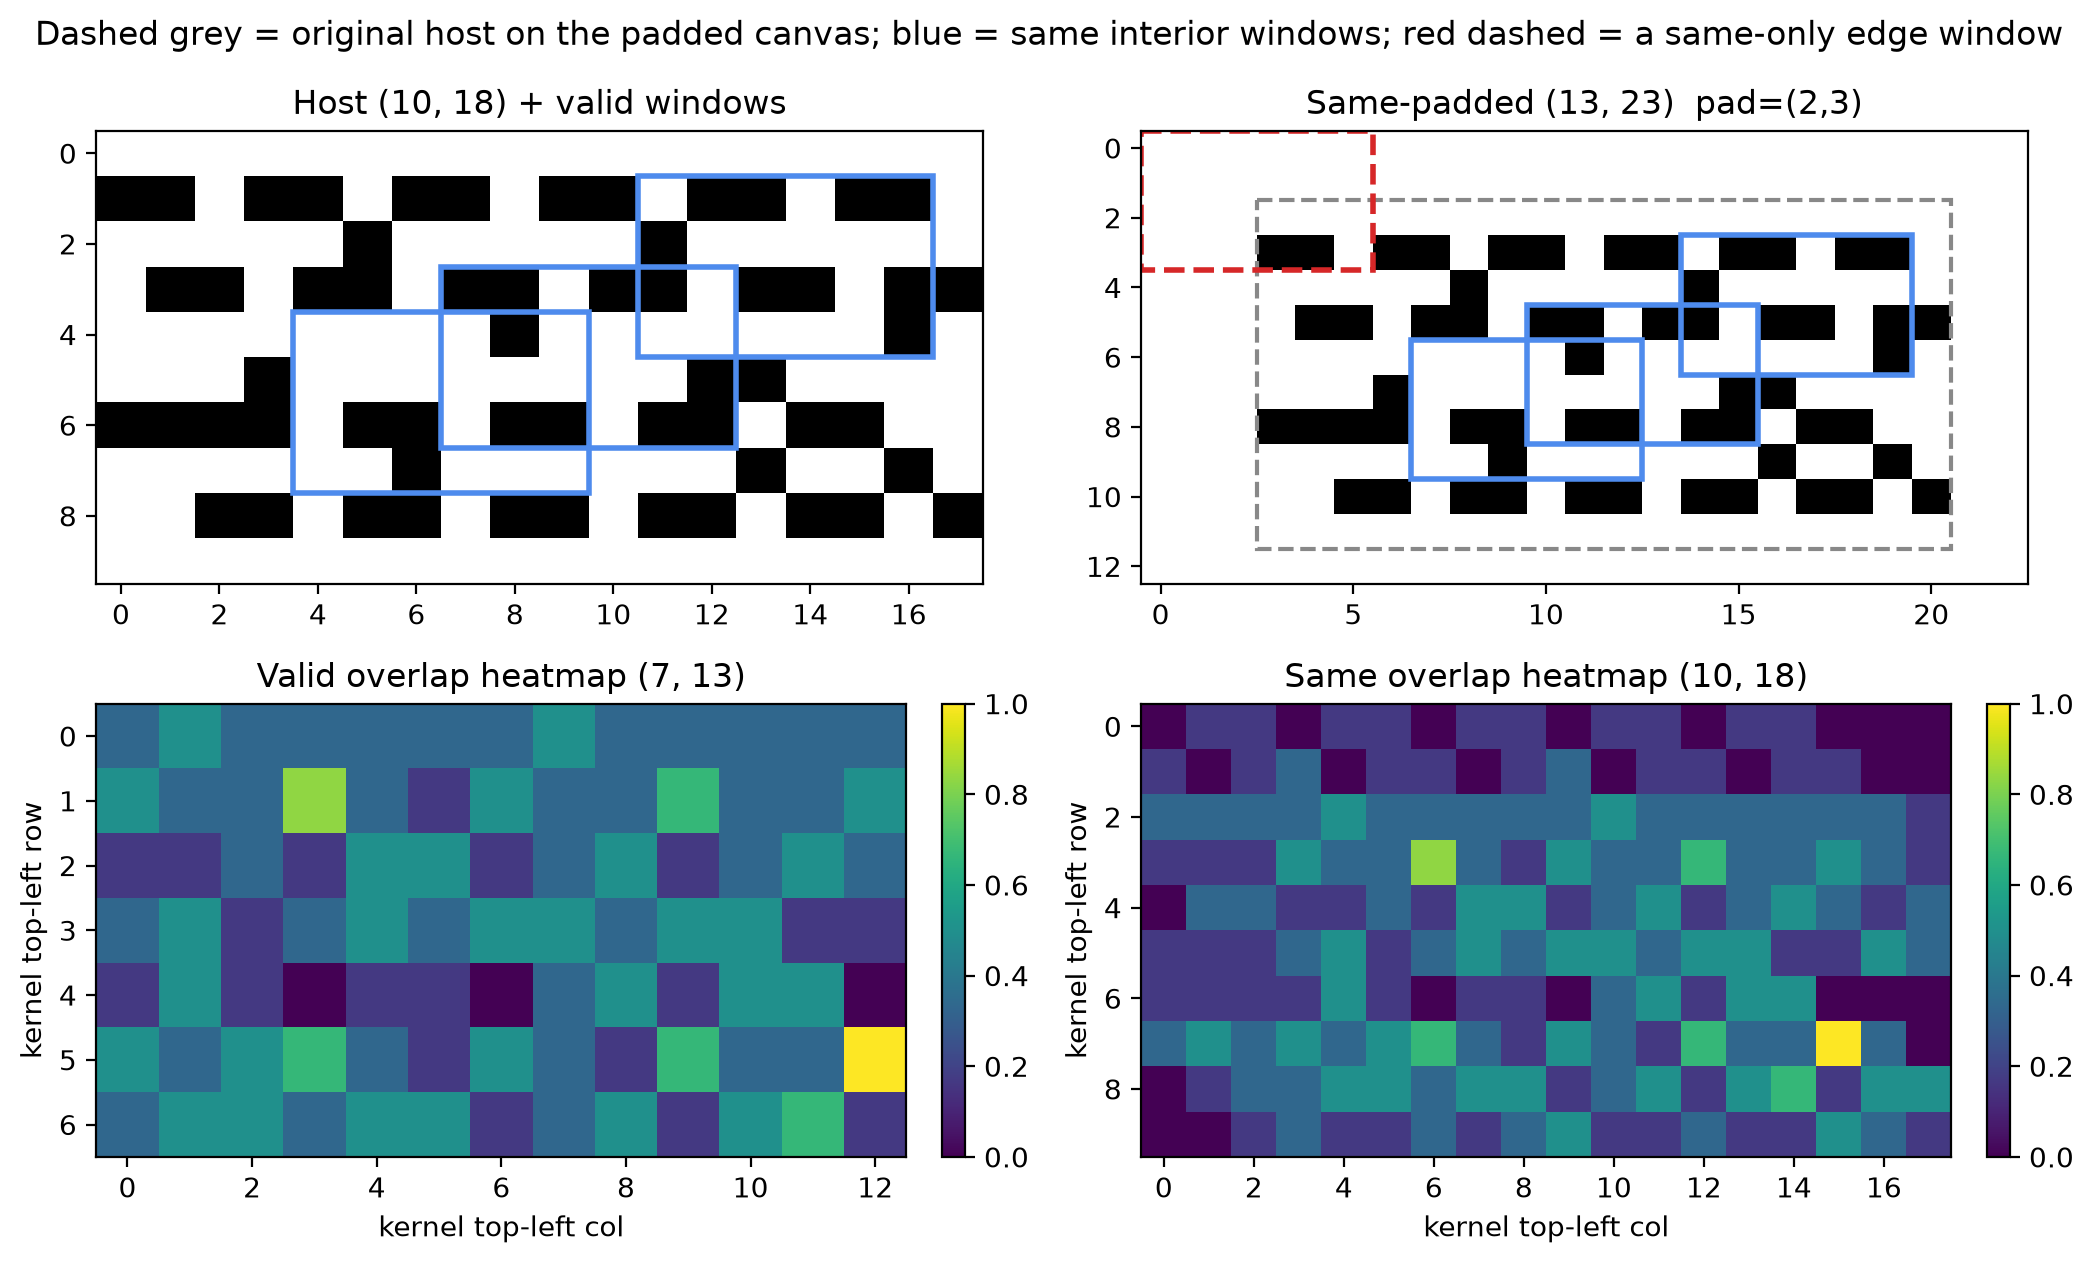

valid: map (7, 13), 91 placements, best=1.000  (run_pattern_search padding='valid')
same:  map (10, 18), 180 placements, best=1.000, padded host (13, 23)  (run_pattern_search padding='same')

Interior windows from the previous cell, now on the padded host:


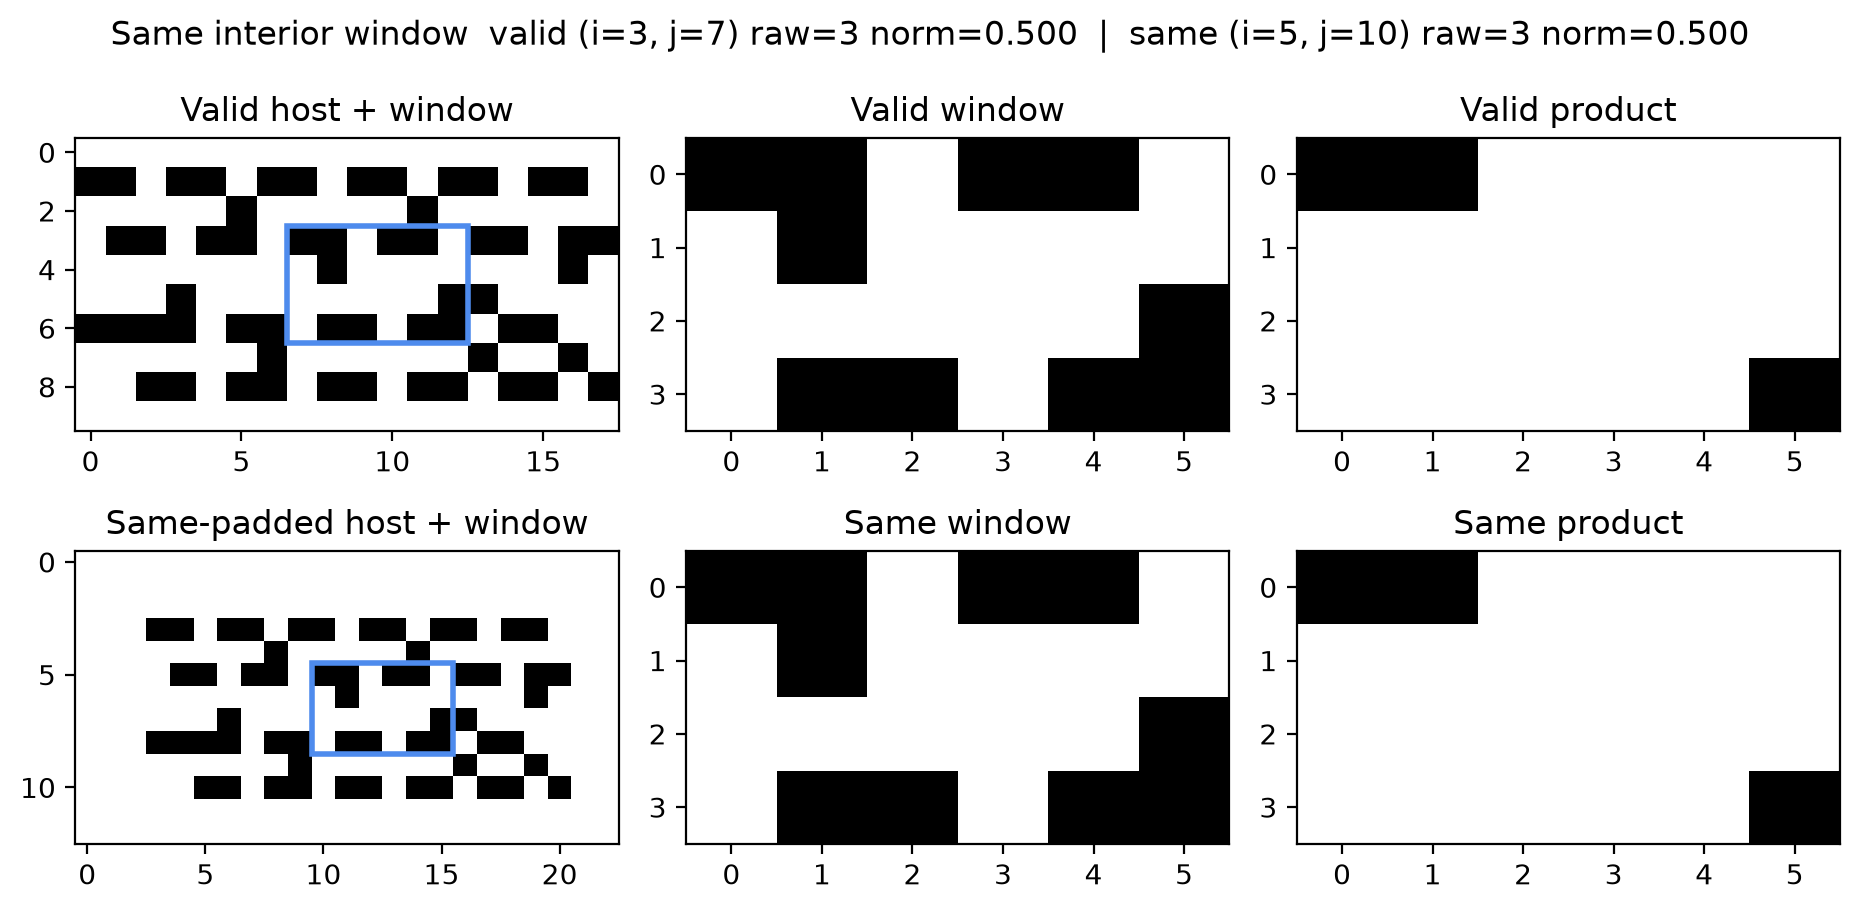

(i=3, j=7) → padded (i=5, j=10): windows identical=True, valid=0.500, same=0.500


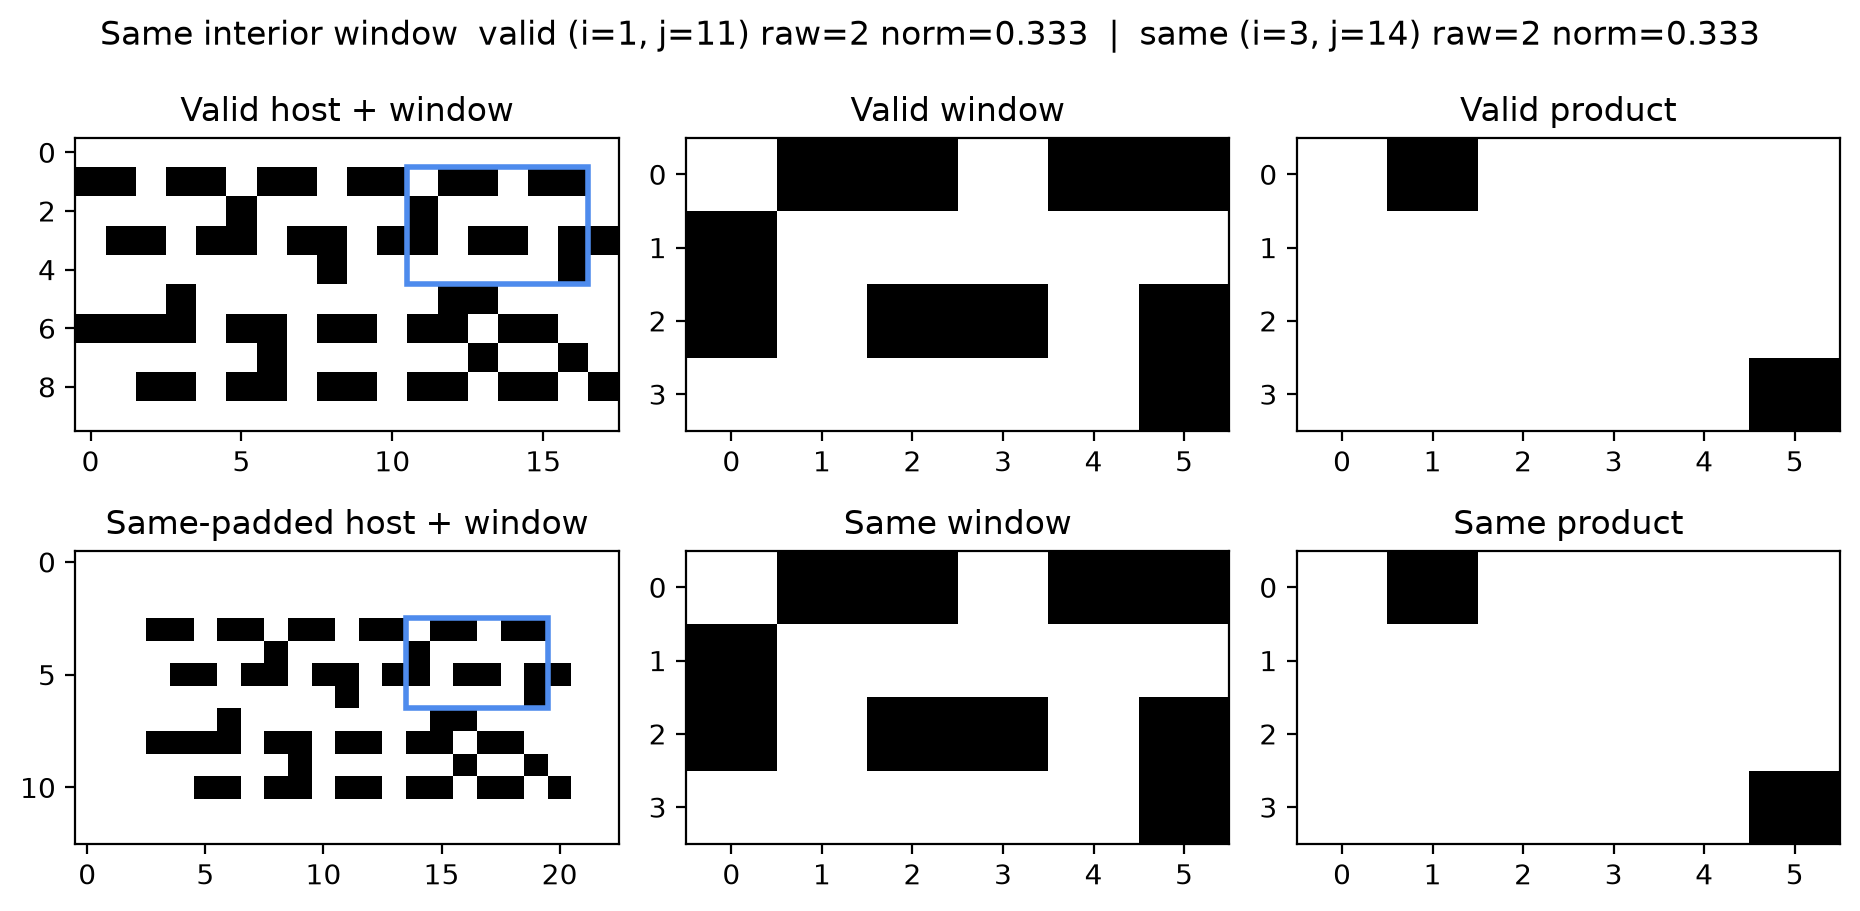

(i=1, j=11) → padded (i=3, j=14): windows identical=True, valid=0.333, same=0.333


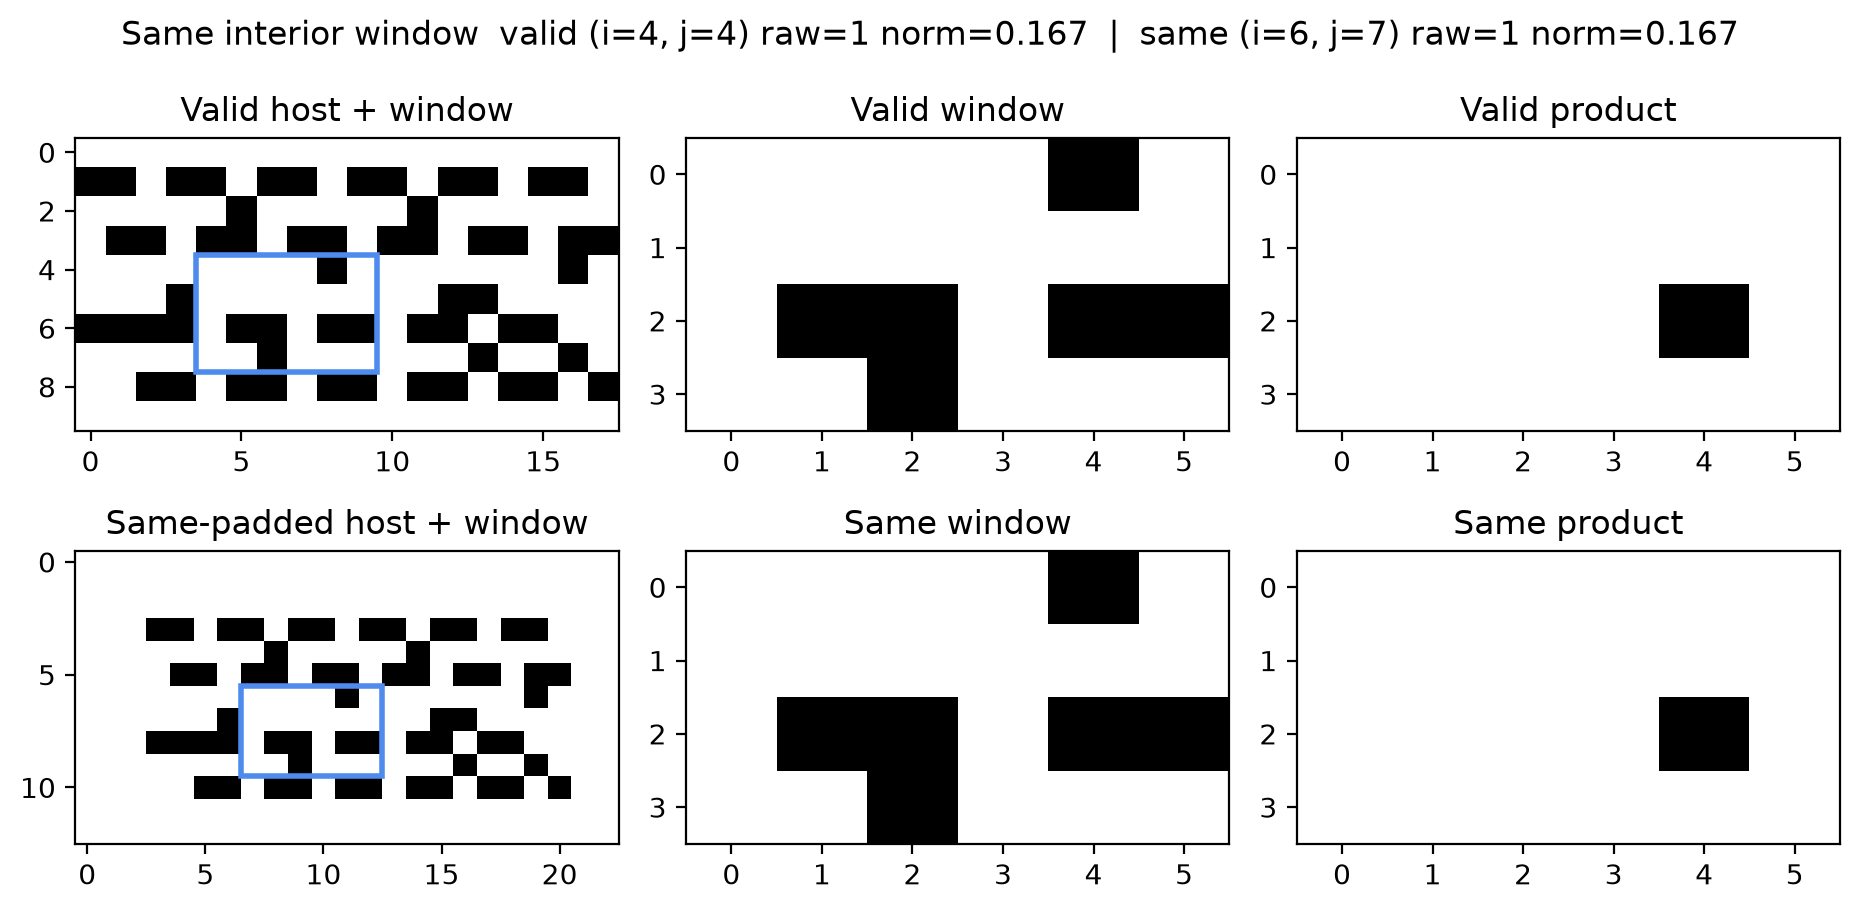

(i=4, j=4) → padded (i=6, j=7): windows identical=True, valid=0.167, same=0.167

A same-only edge window (kernel hangs off the top-left; missing cells are 0):


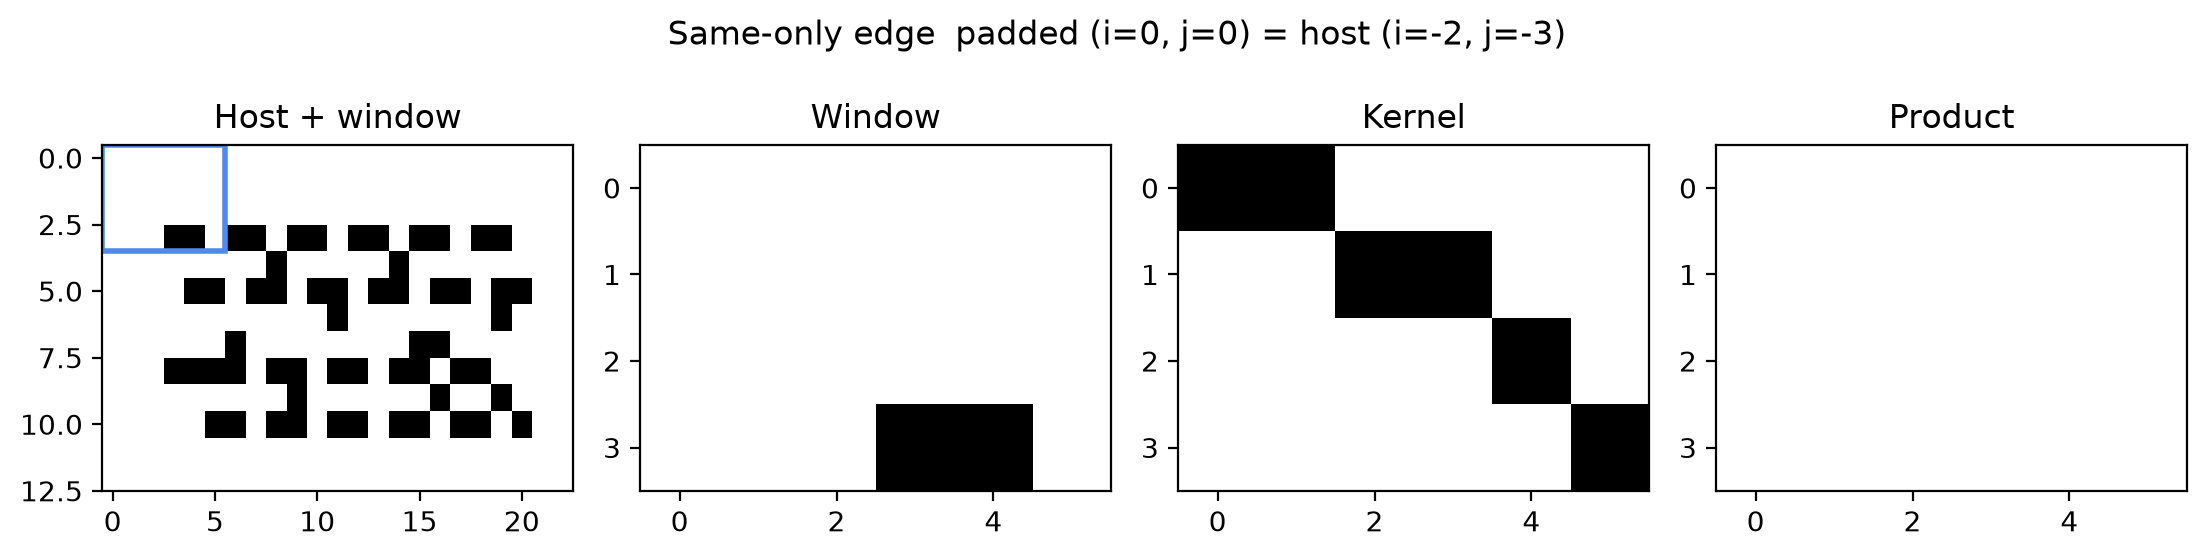

Edge window raw=0 normalised=0.000. This placement does not exist under padding='valid'.


In [69]:
def show_padding_maps(M, K, placements):
    scores_v, _, _, meta_v = convolution_map(M, K, padding="valid")
    scores_s, _, _, meta_s = convolution_map(M, K, padding="same")
    Mp, pad_y, pad_x = pad_for_same(M, K)

    fig, axes = plt.subplots(2, 2, figsize=(10.6, 6.4))
    axes[0, 0].imshow(M, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[0, 0].set_title(f"Host {M.shape} + valid windows")
    for i, j in placements:
        axes[0, 0].add_patch(
            Rectangle(
                (j - 0.5, i - 0.5),
                K.shape[1],
                K.shape[0],
                fill=False,
                edgecolor="#4e8bed",
                linewidth=2,
            )
        )
    axes[0, 1].imshow(Mp, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[0, 1].set_title(f"Same-padded {Mp.shape}  pad=({pad_y},{pad_x})")
    axes[0, 1].add_patch(
        Rectangle(
            (pad_x - 0.5, pad_y - 0.5),
            M.shape[1],
            M.shape[0],
            fill=False,
            edgecolor="#888888",
            linewidth=1.5,
            linestyle="--",
        )
    )
    for i, j in placements:
        axes[0, 1].add_patch(
            Rectangle(
                (j + pad_x - 0.5, i + pad_y - 0.5),
                K.shape[1],
                K.shape[0],
                fill=False,
                edgecolor="#4e8bed",
                linewidth=2,
            )
        )
    axes[0, 1].add_patch(
        Rectangle(
            (-0.5, -0.5),
            K.shape[1],
            K.shape[0],
            fill=False,
            edgecolor="#d62728",
            linewidth=2,
            linestyle="--",
        )
    )
    im_v = axes[1, 0].imshow(
        scores_v, cmap="viridis", origin="upper", aspect="auto", vmin=0, vmax=1
    )
    axes[1, 0].set_title(f"Valid overlap heatmap {scores_v.shape}")
    axes[1, 0].set_xlabel("kernel top-left col")
    axes[1, 0].set_ylabel("kernel top-left row")
    im_s = axes[1, 1].imshow(
        scores_s, cmap="viridis", origin="upper", aspect="auto", vmin=0, vmax=1
    )
    axes[1, 1].set_title(f"Same overlap heatmap {scores_s.shape}")
    axes[1, 1].set_xlabel("kernel top-left col")
    axes[1, 1].set_ylabel("kernel top-left row")
    fig.colorbar(im_v, ax=axes[1, 0], fraction=0.046, pad=0.04)
    fig.colorbar(im_s, ax=axes[1, 1], fraction=0.046, pad=0.04)
    fig.suptitle(
        "Dashed grey = original host on the padded canvas; "
        "blue = same interior windows; red dashed = a same-only edge window"
    )
    fig.tight_layout()
    plt.show()
    print(
        f"valid: map {scores_v.shape}, {scores_v.size} placements, "
        f"best={np.nanmax(scores_v):.3f}  (run_pattern_search padding='valid')"
    )
    print(
        f"same:  map {scores_s.shape}, {scores_s.size} placements, "
        f"best={np.nanmax(scores_s):.3f}, padded host {meta_s['padded_shape']}  "
        f"(run_pattern_search padding='same')"
    )
    return Mp, pad_y, pad_x


def show_valid_vs_same_window(M, K, i, j):
    Mp, pad_y, pad_x = pad_for_same(M, K)
    i_s, j_s = i + pad_y, j + pad_x
    w_v, p_v, raw_v, n_v = score_at(M, K, i, j)
    w_s, p_s, raw_s, n_s = score_at(Mp, K, i_s, j_s)
    fig, axes = plt.subplots(2, 3, figsize=(9.4, 4.6))
    panels = [
        (axes[0, 0], M, True, i, j, "Valid host + window"),
        (axes[0, 1], w_v, False, None, None, "Valid window"),
        (axes[0, 2], p_v, False, None, None, "Valid product"),
        (axes[1, 0], Mp, True, i_s, j_s, "Same-padded host + window"),
        (axes[1, 1], w_s, False, None, None, "Same window"),
        (axes[1, 2], p_s, False, None, None, "Same product"),
    ]
    for ax, data, draw_box, bi, bj, label in panels:
        ax.imshow(data, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
        ax.set_title(label)
        if draw_box:
            ax.add_patch(
                Rectangle(
                    (bj - 0.5, bi - 0.5),
                    K.shape[1],
                    K.shape[0],
                    fill=False,
                    edgecolor="#4e8bed",
                    linewidth=2,
                )
            )
    fig.suptitle(
        f"Same interior window  valid (i={i}, j={j}) raw={raw_v:.0f} norm={n_v:.3f}  |  "
        f"same (i={i_s}, j={j_s}) raw={raw_s:.0f} norm={n_s:.3f}"
    )
    fig.tight_layout()
    plt.show()
    same = np.array_equal(w_v, w_s) and abs(n_v - n_s) < 1e-12
    print(
        f"(i={i}, j={j}) → padded (i={i_s}, j={j_s}): "
        f"windows identical={same}, valid={n_v:.3f}, same={n_s:.3f}"
    )
    return n_v, n_s


if "toy_host" not in globals() or toy_host is None or toy_kernel is None:
    print("Skipped. Run the toy host/kernel cell first.")
else:
    Mp, pad_y, pad_x = show_padding_maps(toy_host, toy_kernel, placements)
    print("\nInterior windows from the previous cell, now on the padded host:")
    for i, j in placements:
        show_valid_vs_same_window(toy_host, toy_kernel, i, j)

    print("\nA same-only edge window (kernel hangs off the top-left; missing cells are 0):")
    show_placement(
        Mp,
        toy_kernel,
        0,
        0,
        title=(
            f"Same-only edge  padded (i=0, j=0) = host (i={-pad_y}, j={-pad_x})"
        ),
    )
    _w, _p, raw_e, n_e = score_at(Mp, toy_kernel, 0, 0)
    print(
        f"Edge window raw={raw_e:.0f} normalised={n_e:.3f}. "
        "This placement does not exist under padding='valid'."
    )


## 3. Parse Bach and crop a readable host patch

Same chorale as the other Workflow 4 notebooks. We keep `Global Onset >= 0`
and then crop the **opening** of the binary matrix so the grids stay readable
in the figures below. Full-score search still uses the same math.

The last figure in the next cell is one Bach placement of the V1 motif at its
natural start — the same window arithmetic as the toy grids.


Processing (verovio): e871590b3deb571b.mei -> 00_e871590b3deb571b
Dropped weaker duplicate MEI text events: 10 row(s) without usable anchors.
Extracted non-barline MEI events: 99 event(s), types=['fermata', 'lyric', 'measure', 'slur', 'tie'].
Full matrix: (37, 192), resolution=0.25
Teaching host crop: (18, 32)
Motif kernel: (6, 16), active=16


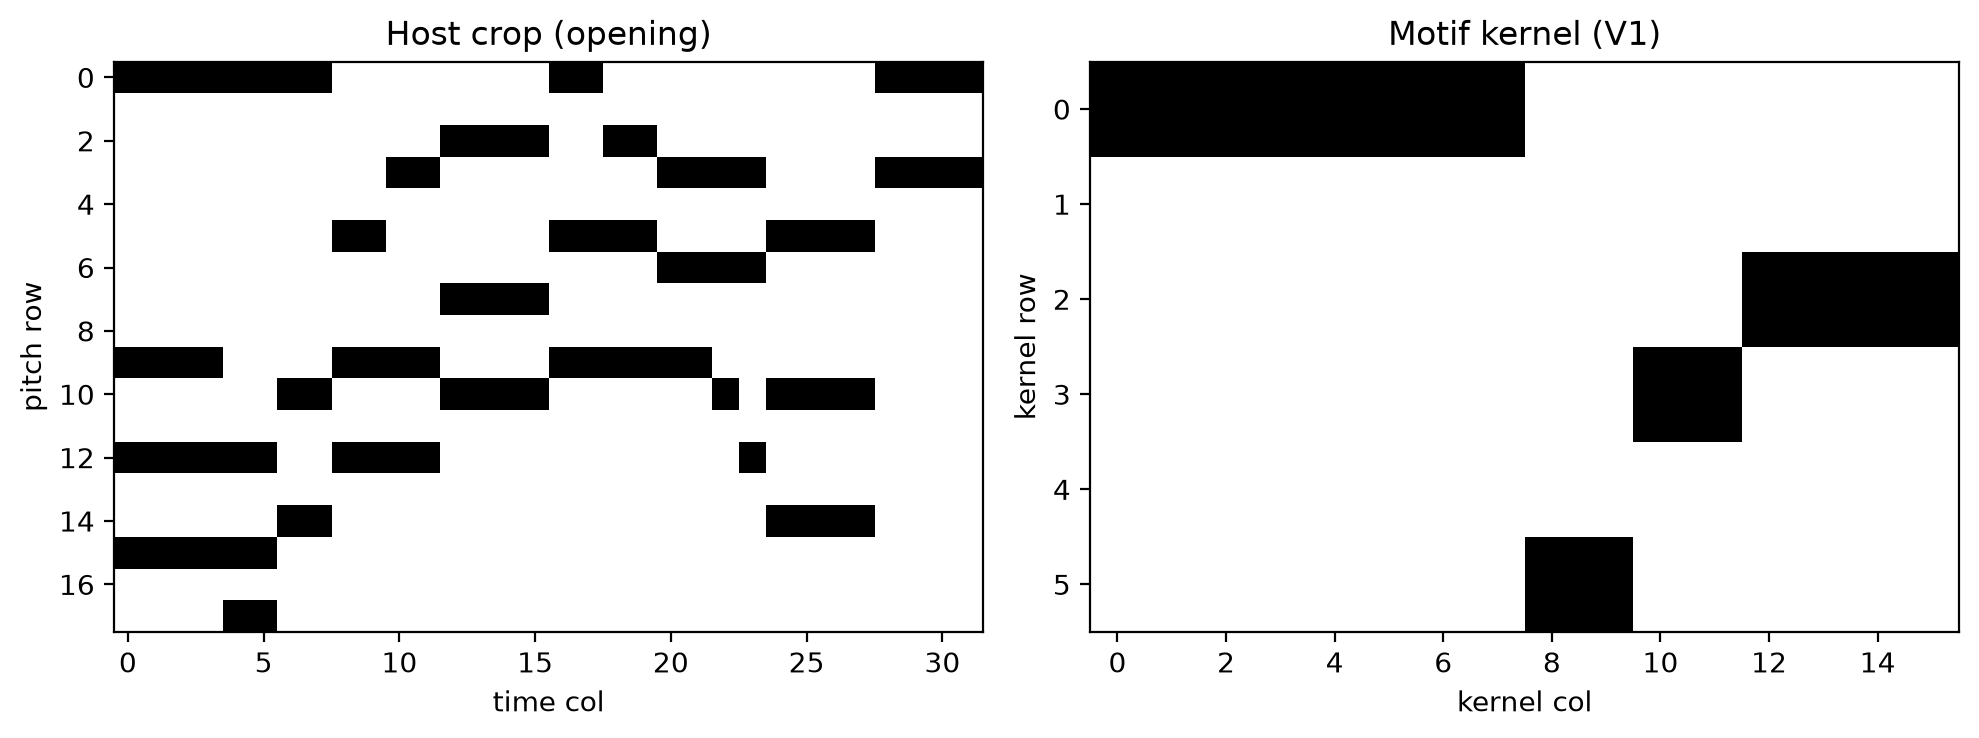


Bach motif on the opening crop:


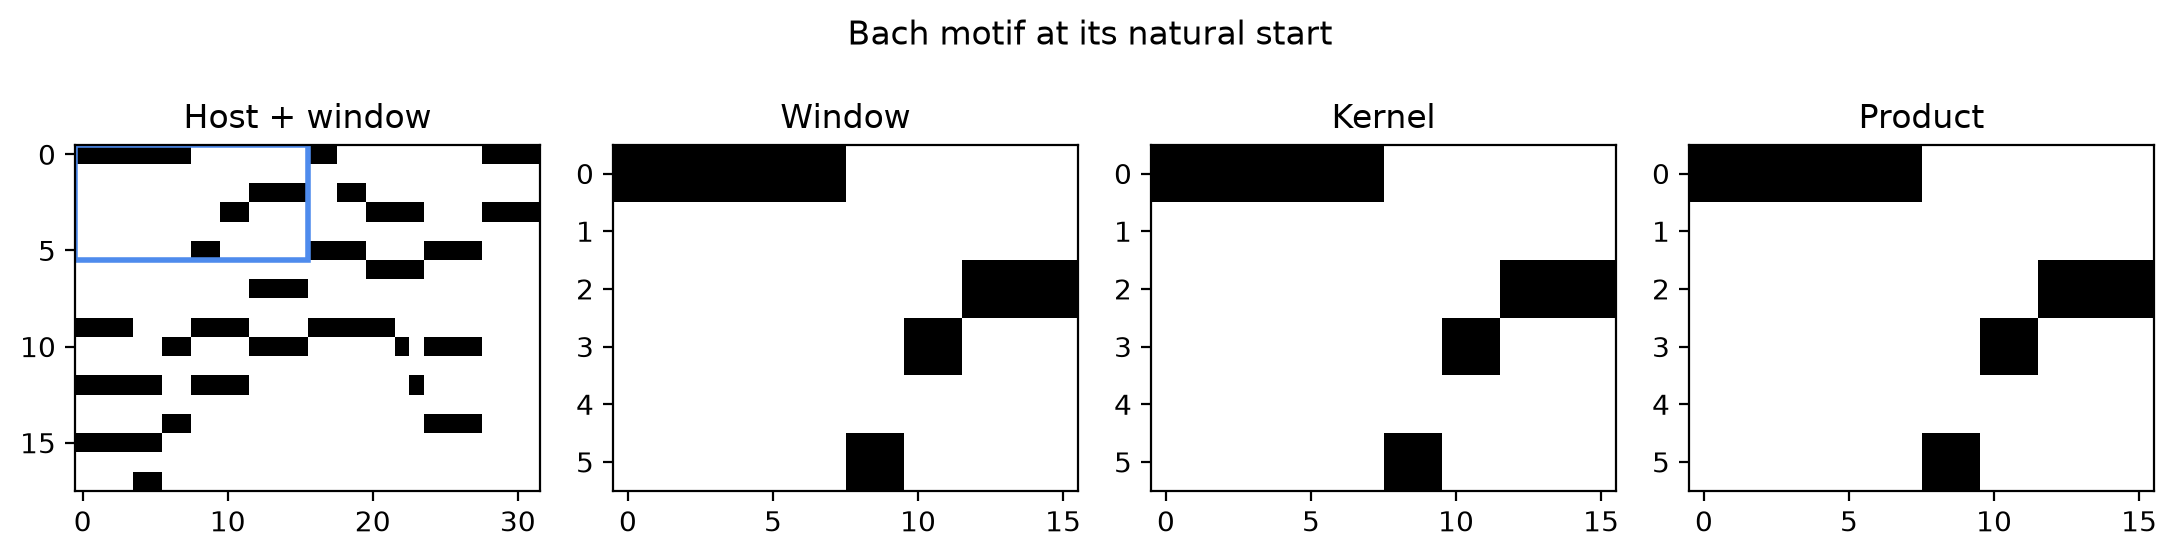

In [70]:
ROOT = find_camat_root()

BACH_SAMPLE_URL = (
    "https://raw.githubusercontent.com/music-encoding/sample-encodings/"
    "main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei"
)

MEI_SOURCE = BACH_SAMPLE_URL
RUN_FETCH = False

# Teaching crop of the host matrix (raw indices)
HOST_ROW_START, HOST_N_ROWS = 0, 18
HOST_COL_START, HOST_N_COLS = 0, 32

mei_path = resolve_mei_source(
    MEI_SOURCE,
    fetch=RUN_FETCH,
    shared_cache=True,
    repo_root=ROOT,
)

if mei_path is None:
    print("Skipped. Set RUN_FETCH = True once, or use a local MEI_SOURCE.")
    binary = None
    host = None
    motif_kernel = None
else:
    results, dfs_by_name, _ = parse_files(
        [str(mei_path)],
        backend="none",
        display_preview_df_pitch=False,
        display_preview_df_events=False,
        include_xml_ids=True,
        parse_enharmonic=True,
        quiet_native_warnings=True,
        use_remote_cache=True,
    )
    df_pitch = results[0]["df_pitch"]
    df_pitch_grid = df_pitch[df_pitch["Global Onset"] >= 0].copy()
    binary = create_binary_matrix_bundle(
        df_pitch_grid,
        source_name="bach_ein_feste_burg",
        results=results,
        resolution_method="auto",
        y_mode="minmax",
        row_order="high_to_low",
        include_provenance=True,
    )
    full = np.asarray(binary.matrix, dtype=float)
    host = full[
        HOST_ROW_START : HOST_ROW_START + HOST_N_ROWS,
        HOST_COL_START : HOST_COL_START + HOST_N_COLS,
    ].copy()

    # Compact monophonic motif from voice 1 (first ~4 QL after time 0)
    motif_notes = df_pitch_grid[
        (df_pitch_grid["Voice"] == "P1 - Voice 1")
        & (df_pitch_grid["Global Onset"] >= 0)
        & (df_pitch_grid["Global Onset"] < 4)
    ].copy()
    motif_bundle = create_binary_matrix_bundle(
        motif_notes,
        source_name="motif_v1",
        resolution_method="manual",
        manual_resolution=float(binary.meta["resolution"]),
        y_mode="minmax",
        midi_low=int(binary.meta["y_min"]),
        midi_high=int(binary.meta["y_max"]),
        row_order=str(binary.meta["row_order"]),
        include_provenance=False,
    )
    mk = np.asarray(motif_bundle.matrix, dtype=float)
    mk = mk[
        HOST_ROW_START : HOST_ROW_START + HOST_N_ROWS,
        HOST_COL_START : HOST_COL_START + HOST_N_COLS,
    ]
    rows = np.where(mk.any(axis=1))[0]
    cols = np.where(mk.any(axis=0))[0]
    motif_kernel = mk[rows.min() : rows.max() + 1, cols.min() : cols.max() + 1].copy()

    print(f"Full matrix: {full.shape}, resolution={binary.meta['resolution']}")
    print(f"Teaching host crop: {host.shape}")
    print(f"Motif kernel: {motif_kernel.shape}, active={int(motif_kernel.sum())}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].imshow(host, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[0].set_title("Host crop (opening)")
    axes[0].set_xlabel("time col")
    axes[0].set_ylabel("pitch row")
    axes[1].imshow(motif_kernel, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[1].set_title("Motif kernel (V1)")
    axes[1].set_xlabel("kernel col")
    axes[1].set_ylabel("kernel row")
    fig.tight_layout()
    plt.show()

    print("\nBach motif on the opening crop:")
    show_placement(host, motif_kernel, i=0, j=0, title="Bach motif at its natural start")


## 4. Sliding window (animation)

Search repeats the placement along every top-left. **Valid** padding (CAMAT's default) keeps the kernel entirely on the host, so the score map is smaller:

$$
H_{\mathrm{out}} = H_{\mathrm{in}} - H_K + 1,\quad
W_{\mathrm{out}} = W_{\mathrm{in}} - W_K + 1
$$

(before stride). The blue box is the kernel, anchored at its **top-left** $(i,j)$, not at its centre. On this Bach crop a valid run therefore **does** start at host column $0$ (the left edge of the first window is the first time column). Two things make that easy to miss:

- the kernel has width $W_K$, so even the first frame already covers columns $0,\ldots,W_K-1$ rather than a single cell;
- later frames move right. With `STRIDE_X = 1` the left edge visits every legal start column; with `STRIDE_X = 2` it visits $0,2,4,\ldots$. It never starts on the last $W_K-1$ host columns, because those starts would hang off the right edge.

The heatmap on the right uses **placement** indices, not host coordinates: its column $0$ is “kernel top-left at host col $0$”, and it is narrower than the host for that reason.

If you step frame-by-frame and the start column jumps ($0,3,7,11,\ldots$) while stride is $1$, that is **animation thinning** (`MAX_FRAMES_VALID` / `MAX_FRAMES_SAME`), not convolution stride. Leave both caps at `None` to visit every legal top-left.

**Same** padding (second animation) zero-pads the host first. The first window then *does* start left of musical column $0$, in the silent border; hanging cells are $0$s. Dashed grey is the original host on that padded canvas. On this crop that is $H\times W = 18\times 32 = 576$ frames vs $13\times 17 = 221$ for valid. Matplotlib's notebook player stores **each frame as an image** in the HTML; the default 20 MB cap is why a full same movie used to drop later frames. The cell below embeds JPEGs so **every** same-padding top-left is included. Sharpen with `ANIM_DPI` (blur) and `JPEG_QUALITY` (blockiness); if the HTML hits `ANIM_EMBED_LIMIT_MB`, raise that cap or lower one of those two. Use the player's step buttons — the clip is long.

Both animations use the Bach motif kernel on the opening crop.


In [71]:
import tempfile
from pathlib import Path


def animate_sliding_window(
    M,
    K,
    stride_y=1,
    stride_x=1,
    max_frames=None,
    interval_ms=180,
    padding="valid",
):
    scores, rows, cols, meta = convolution_map(
        M, K, stride_y=stride_y, stride_x=stride_x, normalize=True, padding=padding
    )
    placements = [(i, j, ii, jj) for ii, i in enumerate(rows) for jj, j in enumerate(cols)]
    n_all = len(placements)
    if max_frames is not None and n_all > int(max_frames):
        idx = np.linspace(0, n_all - 1, int(max_frames)).astype(int)
        placements = [placements[k] for k in idx]
        print(
            f"{padding}: subsampled animation {len(placements)}/{n_all} placements "
            f"(max_frames={int(max_frames)}). Set that cap to None to see every top-left."
        )
    else:
        print(
            f"{padding}: {n_all} frames, one per placement "
            f"(stride=({stride_y},{stride_x}))."
        )

    if padding == "same":
        display_M, pad_y, pad_x = pad_for_same(M, K)
        host_title = f"Same-padded host {display_M.shape} + sliding kernel"
    else:
        display_M, pad_y, pad_x = M, 0, 0
        host_title = f"Host {M.shape} + sliding kernel (valid)"

    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
    ax_m, ax_s = axes
    ax_m.imshow(display_M, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    if padding == "same":
        ax_m.add_patch(
            Rectangle(
                (pad_x - 0.5, pad_y - 0.5),
                M.shape[1],
                M.shape[0],
                fill=False,
                edgecolor="#888888",
                linewidth=1.5,
                linestyle="--",
            )
        )
    rect = Rectangle(
        (-0.5, -0.5),
        K.shape[1],
        K.shape[0],
        fill=False,
        edgecolor="#4e8bed",
        linewidth=2,
    )
    ax_m.add_patch(rect)
    ax_m.set_title(host_title)
    ax_m.set_xlabel("time col")
    ax_m.set_ylabel("pitch row")

    score_img = np.full_like(scores, np.nan)
    im = ax_s.imshow(
        score_img,
        cmap="viridis",
        origin="upper",
        aspect="auto",
        vmin=0,
        vmax=1,
    )
    ax_s.set_title(f"{padding} overlap heatmap (filling in)")
    ax_s.set_xlabel("placement col index")
    ax_s.set_ylabel("placement row index")
    fig.colorbar(im, ax=ax_s, fraction=0.046, pad=0.04)
    fig.tight_layout()

    def update(frame_idx):
        i, j, ii, jj = placements[frame_idx]
        rect.set_xy((j - 0.5, i - 0.5))
        score_img[ii, jj] = scores[ii, jj]
        im.set_data(score_img)
        if padding == "same":
            host_i, host_j = i - pad_y, j - pad_x
            ax_m.set_xlabel(
                f"time col  |  padded (i={i}, j={j})  host (i={host_i}, j={host_j})  "
                f"score={scores[ii, jj]:.2f}"
            )
        else:
            ax_m.set_xlabel(
                f"time col  |  host (i={i}, j={j})  score={scores[ii, jj]:.2f}"
            )
        return (rect, im)

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=len(placements),
        interval=interval_ms,
        blit=False,
        repeat=False,
    )
    plt.close(fig)
    return anim, scores


def display_anim_html(anim, interval_ms, dpi=100, jpeg_quality=85):
    """Embed every frame as JPEG so a full same-padding walk fits in the notebook.

    ``dpi`` is pixels per inch of the figure (raise this if the movie looks
    blurry). ``jpeg_quality`` is 1–95 (raise this if you see blocky artifacts).
    """
    fps = max(1.0, 1000.0 / float(interval_ms))
    writer = animation.HTMLWriter(fps=fps, embed_frames=True, default_mode="once")
    writer.frame_format = "jpeg"
    with tempfile.TemporaryDirectory() as tmp:
        path = str(Path(tmp) / "anim.html")
        anim.save(
            path,
            writer=writer,
            dpi=dpi,
            savefig_kwargs={
                "facecolor": "white",
                "pil_kwargs": {"quality": int(jpeg_quality)},
            },
        )
        display(HTML(Path(path).read_text()))


if host is None or motif_kernel is None:
    print("Skipped. Build the Bach host/kernel first.")
    anim = None
    anim_same = None
    bach_scores = None
    bach_scores_same = None
else:
    h, w = motif_kernel.shape
    H, W = host.shape
    STRIDE_Y, STRIDE_X = 1, 1  # (1, 1) visits every legal top-left
    MAX_FRAMES_VALID = None  # None = every valid placement
    MAX_FRAMES_SAME = None  # None = every same-padding top-left (H×W)
    INTERVAL_MS = 120
    ANIM_DPI = 100  # raise if blurry (72 is soft, 120 is sharp)
    JPEG_QUALITY = 85  # 1–95; raise if blocky, lower if HTML exceeds the embed cap
    ANIM_EMBED_LIMIT_MB = 64  # Matplotlib drops frames above this HTML size
    plt.rcParams["animation.embed_limit"] = ANIM_EMBED_LIMIT_MB
    print(
        f"Kernel {motif_kernel.shape} on host {host.shape}. "
        f"Valid first top-left is (0, 0), covering host cols 0..{w - 1}; "
        f"last legal start col is {W - w} (not {W - 1})."
    )
    print(
        f"Frame counts at stride (1,1): valid "
        f"{(H - h + 1) * (W - w + 1)}, same {H * W}."
    )
    print("Valid padding (kernel stays inside the host):")
    anim, bach_scores = animate_sliding_window(
        host,
        motif_kernel,
        stride_y=STRIDE_Y,
        stride_x=STRIDE_X,
        max_frames=MAX_FRAMES_VALID,
        interval_ms=INTERVAL_MS,
        padding="valid",
    )
    display_anim_html(anim, INTERVAL_MS, dpi=ANIM_DPI, jpeg_quality=JPEG_QUALITY)
    print(
        f"Valid score map {bach_scores.shape}; best={np.nanmax(bach_scores):.3f}"
    )

    print("\nSame padding (kernel may start in the zero border, left of host col 0):")
    anim_same, bach_scores_same = animate_sliding_window(
        host,
        motif_kernel,
        stride_y=STRIDE_Y,
        stride_x=STRIDE_X,
        max_frames=MAX_FRAMES_SAME,
        interval_ms=INTERVAL_MS,
        padding="same",
    )
    display_anim_html(anim_same, INTERVAL_MS, dpi=ANIM_DPI, jpeg_quality=JPEG_QUALITY)
    print(
        f"Same score map {bach_scores_same.shape}; best={np.nanmax(bach_scores_same):.3f}"
    )


Kernel (6, 16) on host (18, 32). Valid first top-left is (0, 0), covering host cols 0..15; last legal start col is 16 (not 31).
Frame counts at stride (1,1): valid 221, same 576.
Valid padding (kernel stays inside the host):
valid: 221 frames, one per placement (stride=(1,1)).


Valid score map (13, 17); best=1.000

Same padding (kernel may start in the zero border, left of host col 0):
same: 576 frames, one per placement (stride=(1,1)).


Same score map (18, 32); best=1.000


## 5. Stride: how far the window jumps

**Stride** $(s_y, s_x)$ is the step between successive top-left corners.

| Stride | Effect |
| --- | --- |
| `(1, 1)` | densest score map; checks every fit |
| `(1, 2)` | skip every other time column (faster, coarser) |
| `(2, 2)` | coarser in pitch and time |

Larger strides shrink the score map roughly by the stride factors. CAMAT
exposes this as `stride_y` / `stride_x` in `run_pattern_search`.


stride=(1,1): placements=221, best=1.000, row stops=[0, 1, 2, 3, 4, 5]...
stride=(1,2): placements=117, best=1.000, row stops=[0, 1, 2, 3, 4, 5]...
stride=(2,2): placements=63, best=1.000, row stops=[0, 2, 4, 6, 8, 10]...
stride=(1,4): placements=65, best=1.000, row stops=[0, 1, 2, 3, 4, 5]...


/tmp/ipykernel_145442/644848751.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


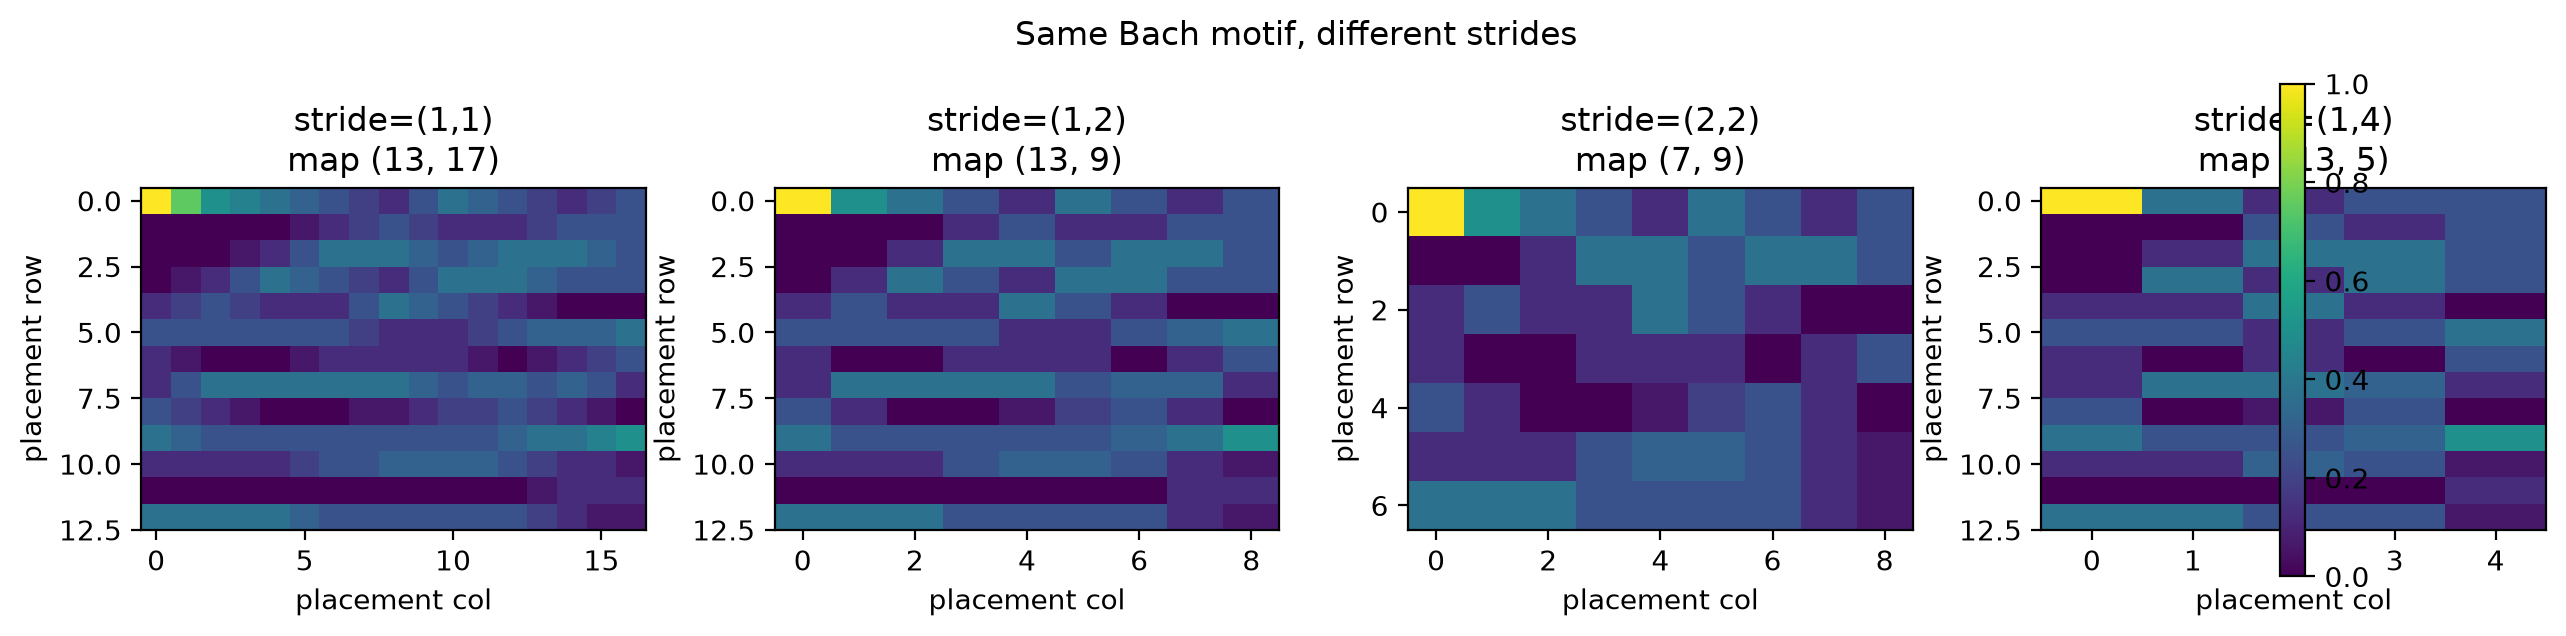

In [72]:
def plot_stride_comparison(M, K, strides):
    n = len(strides)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), squeeze=False)
    for ax, (sy, sx) in zip(axes[0], strides):
        scores, rows, cols, _ = convolution_map(
            M, K, stride_y=sy, stride_x=sx, normalize=True, padding="valid"
        )
        im = ax.imshow(scores, cmap="viridis", origin="upper", aspect="auto", vmin=0, vmax=1)
        ax.set_title(f"stride=({sy},{sx})\nmap {scores.shape}")
        ax.set_xlabel("placement col")
        ax.set_ylabel("placement row")
        print(
            f"stride=({sy},{sx}): placements={scores.size}, "
            f"best={np.nanmax(scores):.3f}, "
            f"row stops={rows[:6]}{'...' if len(rows) > 6 else []}"
        )
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
    fig.suptitle("Same Bach motif, different strides")
    fig.tight_layout()
    plt.show()


if host is None or motif_kernel is None:
    print("Skipped.")
else:
    plot_stride_comparison(host, motif_kernel, strides=[(1, 1), (1, 2), (2, 2), (1, 4)])


## 6. Padding on Bach (valid vs same recap)

Same contrast as the toy section, now on the Bach crop. **Valid** (CAMAT
search) keeps only kernel placements that fit inside the host; **same**
zero-pads the border so the overlap heatmap can match the host size. Interior
scores do not change; new edge scores treat missing cells as silence.


valid: score map (13, 17), placements=221, best=1.000
same: score map (18, 32), placements=576, best=1.000


/tmp/ipykernel_145442/2323175575.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


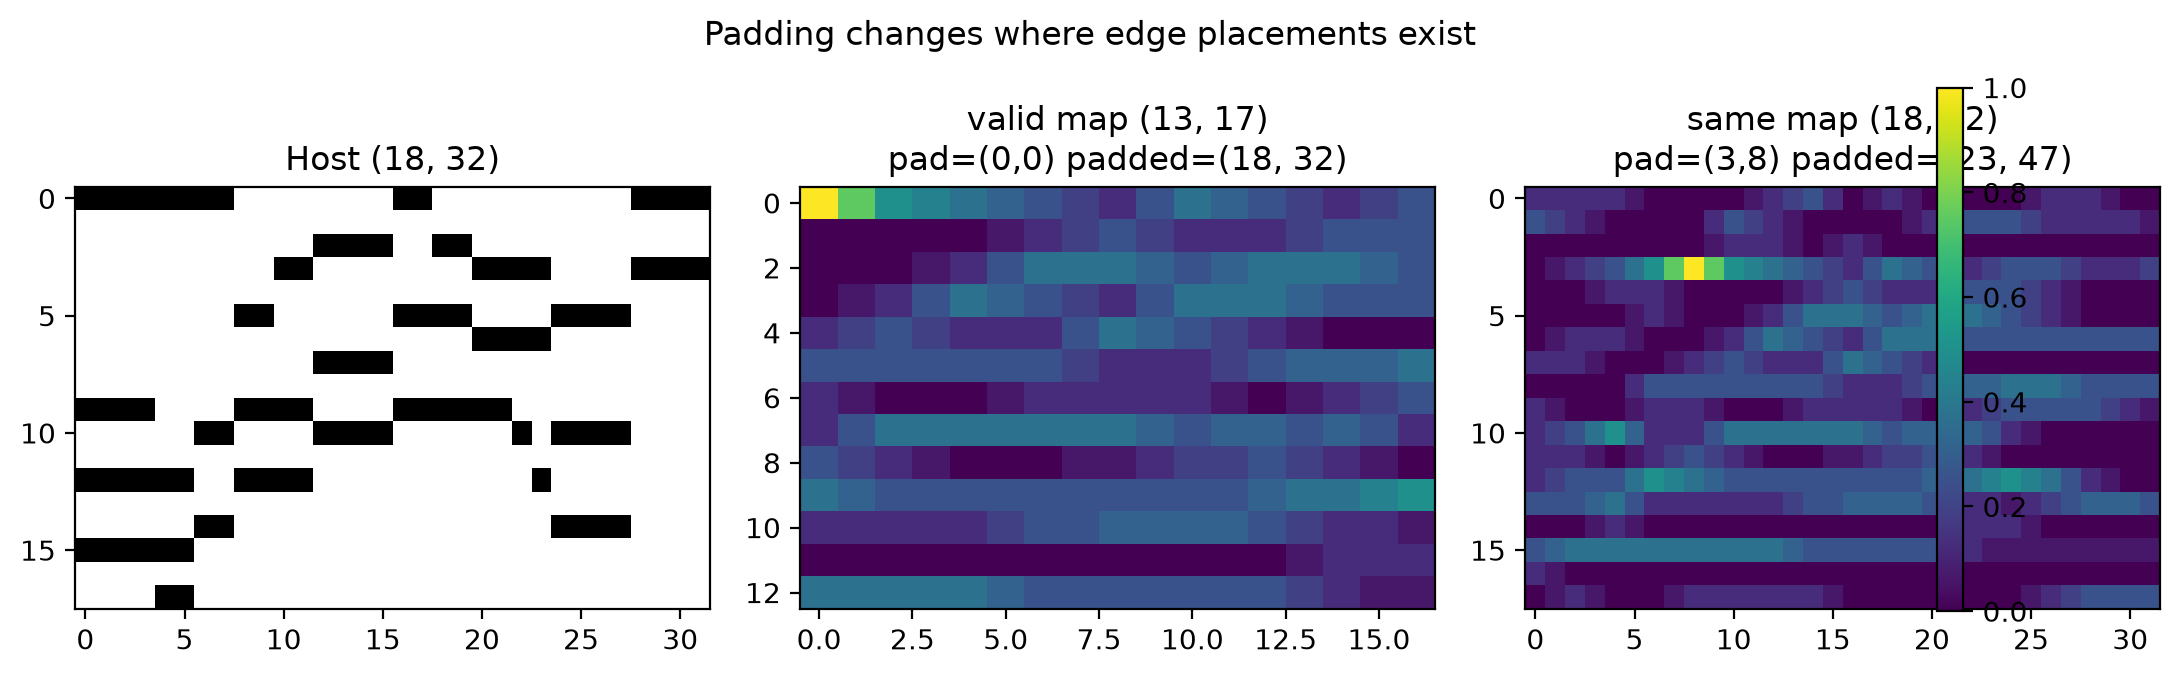

In [73]:
def plot_padding_comparison(M, K):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    axes[0].imshow(M, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
    axes[0].set_title(f"Host {M.shape}")

    for ax, mode in zip(axes[1:], ["valid", "same"]):
        scores, rows, cols, meta = convolution_map(
            M, K, stride_y=1, stride_x=1, normalize=True, padding=mode
        )
        im = ax.imshow(scores, cmap="viridis", origin="upper", aspect="auto", vmin=0, vmax=1)
        ax.set_title(
            f"{mode} map {scores.shape}\n"
            f"pad=({meta['pad_y']},{meta['pad_x']}) padded={meta['padded_shape']}"
        )
        print(
            f"{mode}: score map {scores.shape}, "
            f"placements={scores.size}, best={np.nanmax(scores):.3f}"
        )
    fig.colorbar(im, ax=axes[1:], fraction=0.03, pad=0.02)
    fig.suptitle("Padding changes where edge placements exist")
    fig.tight_layout()
    plt.show()


if host is None or motif_kernel is None:
    print("Skipped.")
else:
    plot_padding_comparison(host, motif_kernel)


## 7. Kernel size (and time scaling)

A **larger kernel** covers more pitch/time context (a phrase, a texture patch).
A **smaller kernel** is more local (a chord, a short motif).

Rhythmic augmentation / diminution is not a different search algorithm: it is
the same convolution with a **resized** kernel. CAMAT's `resize_kernel` (and
`KERNEL_SCALE_FACTORS` in the search notebook) stretches the kernel along `x`
(time), `y` (pitch), or both, then optionally re-binarises it.


scale_x=0.5: kernel (6, 8), map (13, 25), best=1.000
scale_x=0.75: kernel (6, 12), map (13, 21), best=0.917
scale_x=1.0: kernel (6, 16), map (13, 17), best=1.000
scale_x=1.5: kernel (6, 24), map (13, 9), best=0.417


/tmp/ipykernel_145442/2732357593.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


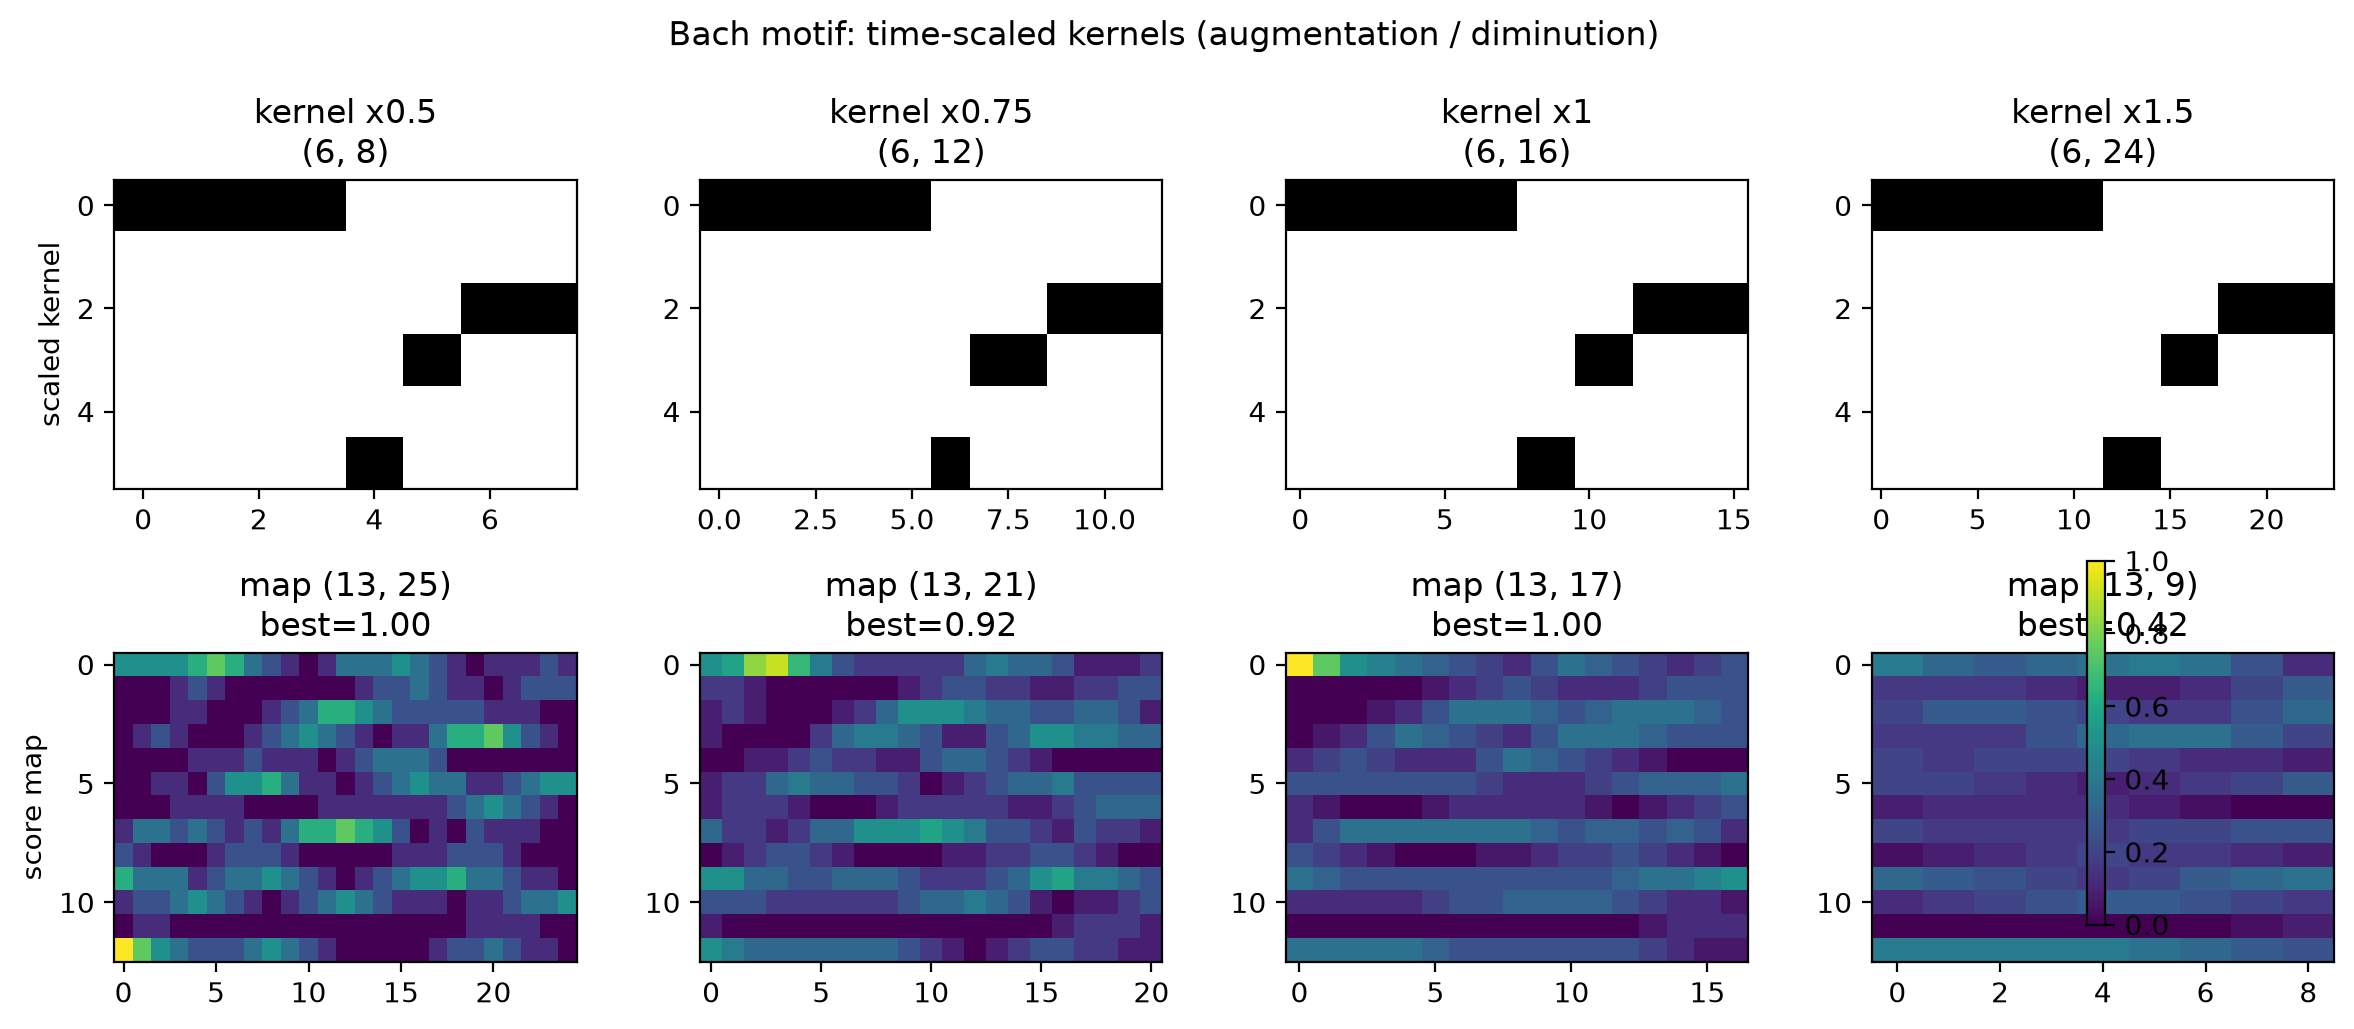

In [74]:
def plot_kernel_scales(M, K, scales_x):
    n = len(scales_x)
    fig, axes = plt.subplots(2, n, figsize=(3.0 * n, 5.2))
    im = None
    for col, sx in enumerate(scales_x):
        Ks = resize_kernel(K, scale_y=1.0, scale_x=float(sx))
        Ks = (Ks >= 0.5).astype(float)
        axes[0, col].imshow(Ks, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
        axes[0, col].set_title(f"kernel x{sx:g}\n{Ks.shape}")
        if Ks.shape[0] > M.shape[0] or Ks.shape[1] > M.shape[1]:
            axes[1, col].set_title("too large for host")
            axes[1, col].axis("off")
            print(f"scale_x={sx}: kernel {Ks.shape} does not fit host {M.shape}")
            continue
        scores, _, _, _ = convolution_map(
            M, Ks, stride_y=1, stride_x=1, normalize=True, padding="valid"
        )
        im = axes[1, col].imshow(
            scores, cmap="viridis", origin="upper", aspect="auto", vmin=0, vmax=1
        )
        axes[1, col].set_title(f"map {scores.shape}\nbest={np.nanmax(scores):.2f}")
        print(
            f"scale_x={sx}: kernel {Ks.shape}, map {scores.shape}, "
            f"best={np.nanmax(scores):.3f}"
        )
    axes[0, 0].set_ylabel("scaled kernel")
    axes[1, 0].set_ylabel("score map")
    if im is not None:
        fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.02, pad=0.02)
    fig.suptitle("Bach motif: time-scaled kernels (augmentation / diminution)")
    fig.tight_layout()
    plt.show()


if host is None or motif_kernel is None:
    print("Skipped.")
else:
    plot_kernel_scales(host, motif_kernel, scales_x=[0.5, 0.75, 1.0, 1.5])


## 8. Filmstrip: a few Bach placements side by side

Static frames help when you want to pause on specific overlaps without the
animation. Each panel is one top-left $(i, j)$ with its normalised score.


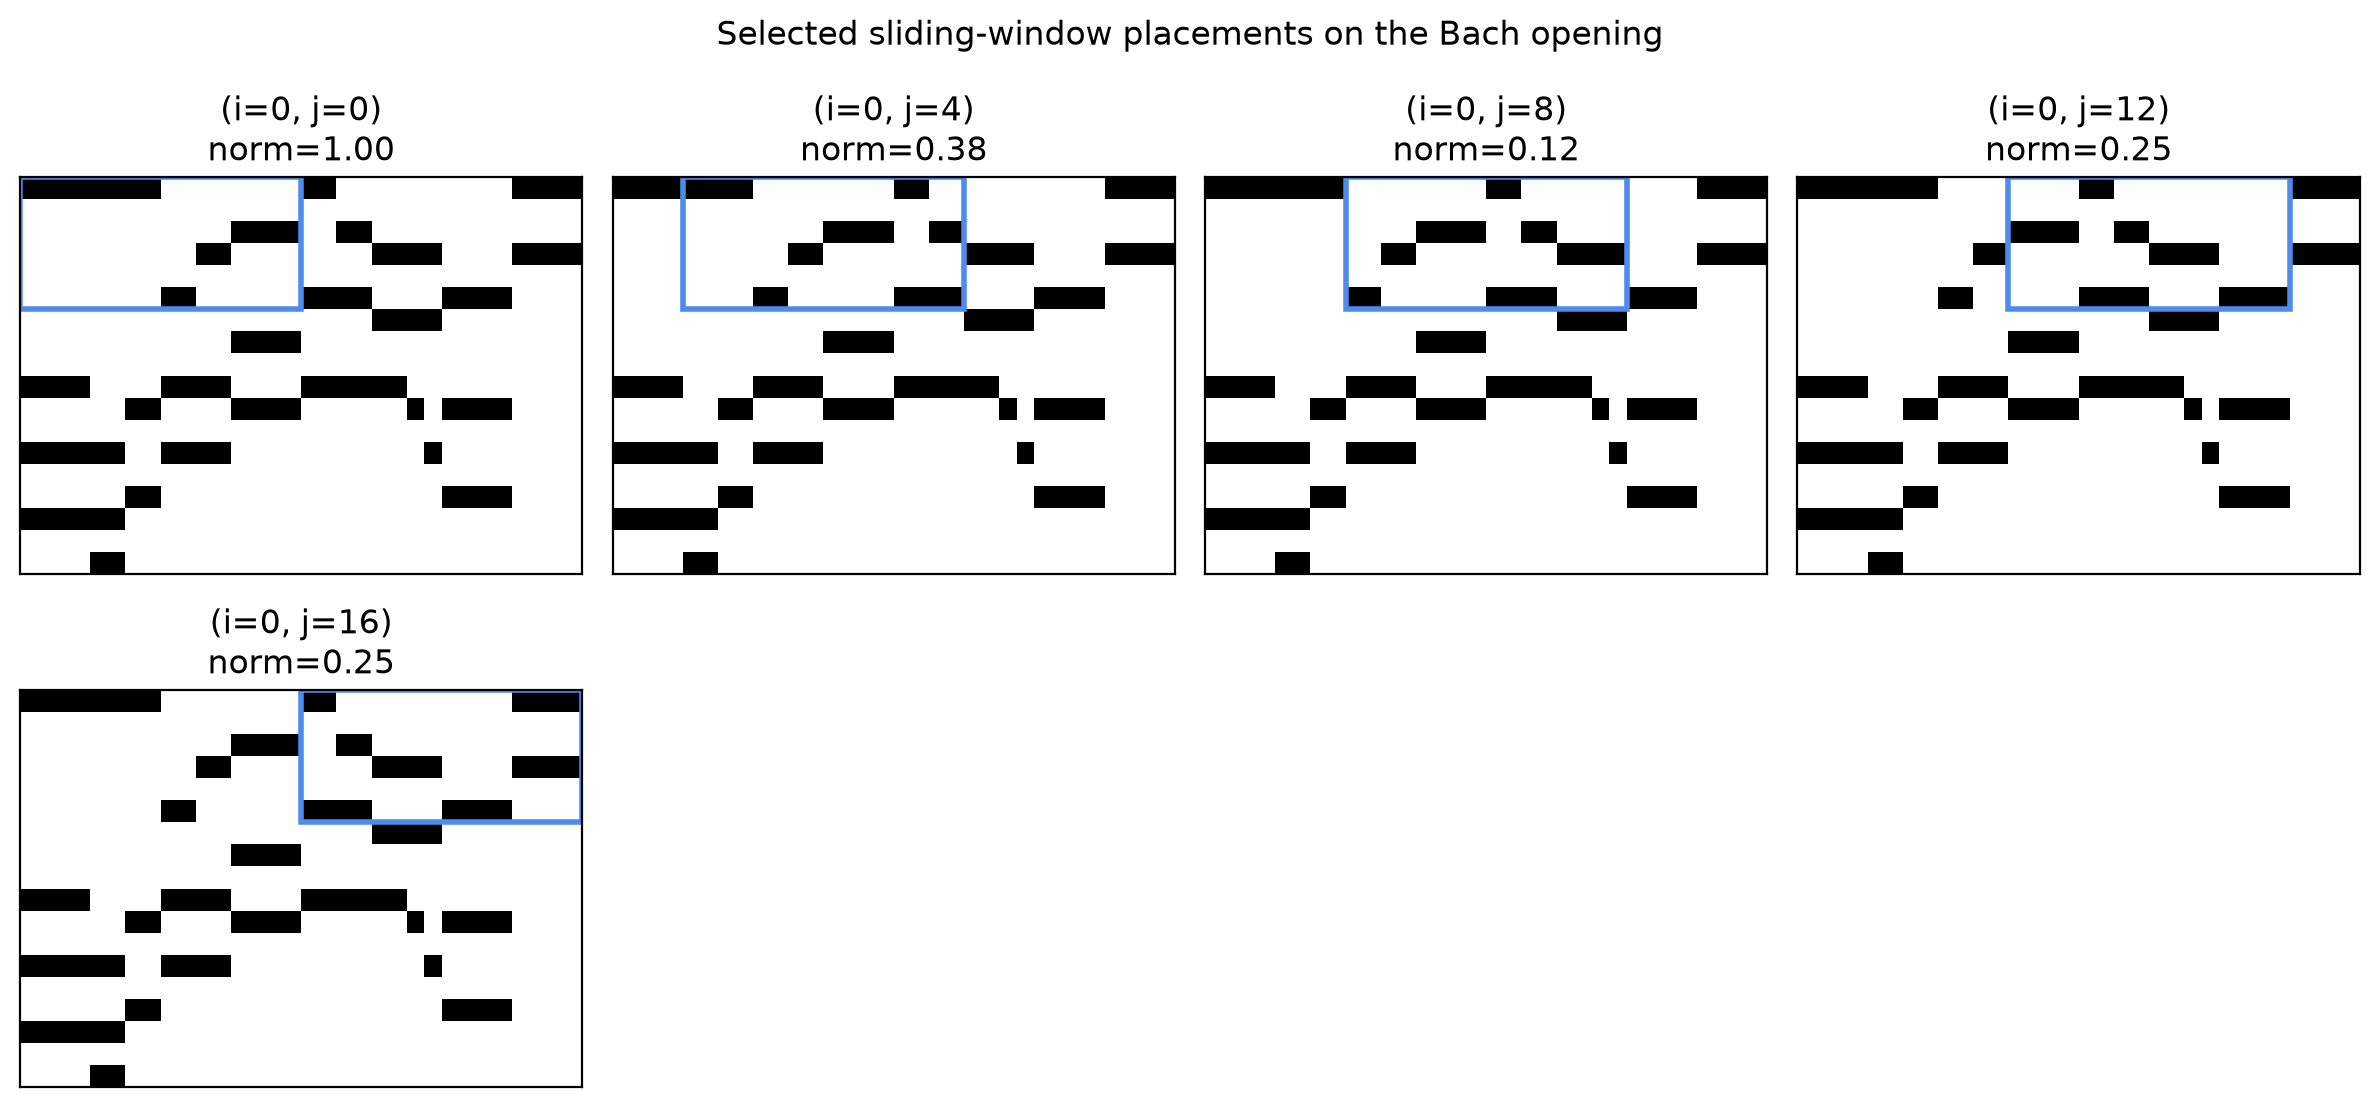

In [75]:
def filmstrip_placements(M, K, placements, ncols=4):
    n = len(placements)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.8 * nrows))
    axes = np.atleast_2d(axes)
    for ax, (i, j) in zip(axes.ravel(), placements):
        ax.imshow(M, cmap="Greys", origin="upper", aspect="auto", vmin=0, vmax=1)
        _, _, raw, norm = score_at(M, K, i, j)
        ax.add_patch(
            Rectangle(
                (j - 0.5, i - 0.5),
                K.shape[1],
                K.shape[0],
                fill=False,
                edgecolor="#4e8bed",
                linewidth=2,
            )
        )
        ax.set_title(f"(i={i}, j={j})\nnorm={norm:.2f}")
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle("Selected sliding-window placements on the Bach opening")
    fig.tight_layout()
    plt.show()


if host is None or motif_kernel is None:
    print("Skipped.")
else:
    rows, cols = valid_placements(host.shape, motif_kernel.shape, stride_y=1, stride_x=4)
    demo = [(0, j) for j in cols[:8]]
    filmstrip_placements(host, motif_kernel, demo, ncols=4)


## What was produced?

- A student-tunable toy host/kernel catalog with random, planted, or fixed
  placements (empty windows skipped in random mode).
- An overlap heatmap (one normalised score per kernel position) and the same
  toy windows compared under **valid** vs **same** padding.
- A Bach opening host crop and a V1 motif kernel (same chorale as the search notebook).
- A sliding-window animation that fills a normalised-overlap map for **valid**
  and **same** padding.
- Side-by-side comparisons for **stride** and **kernel time scales**, plus a
  Bach recap of valid vs same maps.
- A static filmstrip of selected placements.

CAMAT search (`run_pattern_search`) defaults to **valid** padding and exposes
`padding="valid"|"same"`, stride, and kernel scale factors — the same knobs
visualised here.

**Next:** [`binary_pattern_search.ipynb`](binary_pattern_search.ipynb) runs motif /
chord / texture searches and overlays matches on the piano roll. Guide:
[Analyse representations](../docs/guides/analysis.md).
